This notebook is used to simplify the code of the Zhu model and verify the plots with the Andrews model .

In [1]:
# import everything first

# import everything first:
import numpy as np
import astropy.constants as const
import astropy.units as u
from matplotlib import pyplot as plt
import sys
import pickle
from joblib import load
from joblib import Parallel, delayed
import os
import pandas as pd

In [2]:

%load_ext autoreload
%autoreload 2

In [3]:
# ============================
# Physical constants (CGS)
# ============================

G          = 6.674e-8            # gravitational constant [cm^3 g^-1 s^-2]
sigmaB     = 5.670e-5            # Stefan–Boltzmann constant [erg cm^-2 s^-1 K^-4]
kB         = 1.381e-16           # Boltzmann constant [erg K^-1]

# Luminosities
L_sun      = 3.828e33            # solar luminosity [erg/s]
L_jup      = 3.846e30            # Jupiter luminosity [erg/s] (your input)

# Distances
AU         = 1.496e13            # astronomical unit [cm]

# Masses
M_sun      = 1.989e33            # [g]
M_jup      = 1.898e30            # [g]

# Radii
R_jup      = 7.149e9             # Jupiter radius [cm]

# Time
sec_per_yr = 3.156e7             # seconds in one year

# Gas constant
Rgas       = 8.314e7             # erg mol^-1 K^-1  (used in Zhu eq. 6 and 7)


Import the luminosity and planet radius relationship from the Andrews Model.

In [4]:
Lp_from_Mp = load('d:/CPD_MPIA/utils/Lp_from_Mp.pkl')
Rp_from_Mp = load('d:/CPD_MPIA/utils/Rp_from_Mp.pkl')

Define the Planck's function as a function of wavelength.

In [5]:
def B_lambda(lam, T):
    """
    Planck function in wavelength (erg s^-1 cm^-2 Hz^-1 sr^-1)
    lam: wavelength in cm
    T: temperature in K
    """
    h = 6.626e-27  # erg*s
    c = 2.998e10   # cm/s
    k = 1.381e-16  # erg/K
    return (2*h*c**2 / lam**5) / (np.exp(h*c/(lam*k*T)) - 1)

Define the Zhu model here.


For the test of the DSHARP gaps,  default parameters used will be

|Mdot|alpha|lambda|
|-|-|-|
| 1.56e-6 M_jup/yr |1e-3 |1.3 mm|


Additional Parameters fixed here but not found in the Andrews model: 


| mu| kappaR| T_ISM|
|-|-|-|
|2.3| 10 cm^2/g|10 K|



HD1423006 specific parameter from DSHARP era:

|M_star | d_pc | Lum_star | 
|-|-|-|
|1.56 M_sun| 167 pc| 3.8 L_sun|


In [82]:
import numpy as np

# -------------------------------
# PHYSICAL CONSTANTS
# -------------------------------

# assume you already have G, sigmaB, kB, AU, R_jup, M_jup, M_sun, sec_per_yr etc.


# ================================================================
# A. UNITS AND RADIAL GRID
# ================================================================

def convert_inputs(M_star, Mp, Mdot, rp, Lstar):
    M_star = M_star * M_sun
    Mp     = Mp     * M_jup
    Mdot   = Mdot   * M_jup / sec_per_yr # from M_jup/yr to g/s
    rp     = rp     * AU
    Lstar  = Lstar  * L_sun
    Rp = Rp_from_Mp(Mp / M_jup) * R_jup     # [cm]
    # Luminosities
    Lplanet = Lp_from_Mp(Mp / M_jup) * L_sun  # [erg/s]
    return M_star, Mp, Mdot, rp, Lstar, Rp, Lplanet

def radial_grid(Rp, Rout, Nr=200):
    R = np.geomspace(Rp*1.01, Rout, Nr)
    return R


# ================================================================
# B. HEATING: IRRADIATION AND EFFECTIVE TEMPERATURE
# ================================================================

def irradiation_temperature(R, Rp, Mp, Mdot, Lplanet, Lstar, rp, T_ISM):
    # boundary layer accretion luminosity

    L_irr = G*Mp*Mdot/(2*Rp)
    T_irr = ( L_irr / (40*np.pi*sigmaB*R**2) )**0.25

    # intrinsic planet irradiation
    T_irr_p = (0.1 * Lplanet / (4*np.pi*sigmaB*R**2))**0.25

    # stellar irradiation at distance rp
    phi = 0.02
    T_irr_star = ( phi * Lstar / (8*np.pi*sigmaB*rp**2) )**0.25

    T_ext = (T_irr**4 + T_irr_p**4 + T_irr_star**4 + T_ISM**4)**0.25
    return T_ext, T_irr, T_irr_p, T_irr_star


def effective_temperature(R, Rp, Mp, Mdot):
    Teff = ( (3*G*Mp*Mdot)/(8*np.pi*sigmaB*R**3) * (1 - np.sqrt(Rp/R)) )**0.25
    return Teff


# ================================================================
# C. SURFACE DENSITY
# ================================================================

def sigma_viscous(R, Rp, Mp, Mdot, alpha, kappaR, mu):
    # eq. (6) Zhu 2018
    Rgas = 8.314e7
    term = (sigmaB*G*Mp*Mdot**3/(alpha**4*np.pi**3*kappaR))**0.2
    mu_t = (mu/Rgas)**0.8
    fac = (1 - np.sqrt(Rp/R))**(3/5)
    Sigma6 = (2**(7/5)/3**(6/5)) * term * mu_t * fac * R**(-3/5)
    return Sigma6


def sigma_irradiated(R, Mp, Mdot, alpha, mu, T_ext):
    # eq. (7) Zhu 2018
    Rgas = 8.314e7
    Omega = np.sqrt(G*Mp/R**3)
    Sigma7 = (Mdot * mu * Omega) / (3*np.pi*alpha*Rgas*T_ext)
    return Sigma7


def sigma_combined(Sigma6, Sigma7):
    # physical regime takes the LOWER Σ
    return np.minimum(Sigma6, Sigma7)


# ================================================================
# D. MIDPLANE TEMPERATURE
# ================================================================

def midplane_temperature(R, Rp, Mp, Mdot, Sigma, kappaR, T_ext):
    A = (9*G*Mp*Mdot*Sigma*kappaR)/(128*np.pi*sigmaB*R**3)
    f = (1 - np.sqrt(Rp/R))
    Tc = (A*f + T_ext**4)**0.25
    return Tc


# ================================================================
# E. OPTICAL DEPTH AND BRIGHTNESS TEMPERATURE
# ================================================================

def tau_mm(Sigma, lam_mm):
    kappa_mm = 0.034 * (0.87/lam_mm)
    return 0.5 * kappa_mm * Sigma, kappa_mm


def Tb_from_tau(R, tau, Tc, Teff, T_ext, kappaR, kappa_mm):
    # thin approx
    Tb_thin = 2 * tau * Tc

    # thick approx (Zhu eq. 8 adaptation)
    Tb_thick = ((3/8)*(kappaR/kappa_mm)*Teff**4 + T_ext**4)**0.25

    Tb = np.where(tau <= 0.5, Tb_thin, Tb_thick)
    return Tb


# ================================================================
# F. FLUX INTEGRATION
# ================================================================

def flux_mm(R, Tb, lam_mm, d_pc ,Sigma, L_planet):
    # ================================================================
    # === 9. Flux Density (Rayleigh-Jeans Approximation) =============
    # ================================================================
    Rmid = 0.5 * (R[:-1] + R[1:])
    dR = np.diff(R)
    I_RJ = 2.0 * kB * Tb / (lam_mm * 0.1)**2                                 # [erg cm^-2 s^-1 Hz^-1 sr^-1]
    F_nu_mid = 0.5 * (I_RJ[:-1] + I_RJ[1:])
    F_nu_tot = np.sum(F_nu_mid * 2 * np.pi * Rmid * dR)                      # [erg s^-1 Hz^-1]

    d_cm = d_pc * 3.086e18                                                   # [cm]
    F_nu_obs = F_nu_tot / d_cm**2                                            # [erg s^-1 cm^-2 Hz^-1]
    F_microJy = F_nu_obs / 1e-29                                             # [µJy]

    # Add the jet wind flux
    #F_extra = 8e3 * (L_planet/L_sun)**0.6 / (d_pc**2)  # mJy
    #F_microJy= F_microJy + F_extra*1e3  # µJy

    # ================================================================
    # === 10. Equaate CPD mass to power law sigma to sigma ===========
    # ================================================================
    M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]
    return F_microJy, M_dust


# ================================================================
# G. MASTER FUNCTION
# ================================================================

def calculate_disk_properties_zhu(M_star=1.0, Mp=1.0, Mdot=1e-6, alpha=1e-3, rp=20,
                  lam_mm=1.3, T_ISM=10, Lstar=1.0, kappaR=10, mu=2.3,
                  d_pc=140, Rout=None, Nr=200):

    # convert
    M_star, Mp_cgs, Mdot_cgs, rp_cgs, Lstar_cgs,Rp_cgs, Lplanet = convert_inputs(
        M_star, Mp, Mdot, rp, Lstar
    )



    # outer radius
    if Rout is None:
        Rout_cgs = (1/3)*rp_cgs*(Mp_cgs/(3*M_star))**(1/3)
    else:
        Rout_cgs = Rout*AU

    # grid
    R = radial_grid(Rp_cgs, Rout_cgs, Nr)

    # heating
    T_ext, T_irr, T_irr_p, T_irr_star = irradiation_temperature(R, Rp_cgs, Mp_cgs, Mdot_cgs,
                                                               Lplanet, Lstar_cgs, rp_cgs, T_ISM)
    Teff  = effective_temperature(R, Rp_cgs, Mp_cgs, Mdot_cgs)

    # Σ
    Sigma6 = sigma_viscous(R, Rp_cgs, Mp_cgs, Mdot_cgs, alpha, kappaR, mu)
    Sigma7 = sigma_irradiated(R, Mp_cgs, Mdot_cgs, alpha, mu, T_ext)
    Sigma  = sigma_combined(Sigma6, Sigma7)

    # Tc
    Tc = midplane_temperature(R, Rp_cgs, Mp_cgs, Mdot_cgs, Sigma, kappaR, T_ext)

    # τ, Tb
    tau, kappa_mm = tau_mm(Sigma, lam_mm)
    Tb = Tb_from_tau(R, tau, Tc, Teff, T_ext, kappaR, kappa_mm)

    # flux
    F_microJy, M_dust = flux_mm(R, Tb, lam_mm, d_pc,Sigma, Lplanet)

    return {
        "R": R,
        "R_out": Rout,
        "R_AU": R / AU,
        "T_ext": T_ext,
        "Teff": Teff,
        "T_c": Tc,
        "Tb": Tb,
        "Sigma": Sigma,
        "tau_mm": tau,
        "F_nu_tot": F_microJy,
        "M_dust": M_dust,
        "T_irr": T_irr,
        "T_irr_p": T_irr_p,
        "T_irr_star": T_irr_star,
    }



Define the compute flux function.


What needs to be careful here:
- Not mixing up KappaR and KappaMM
- Not mixing up rp (AU) and Rp(Rjup)
- The nested loop picking up correct indices.

In [83]:
def zhu_plots_flux_map(target_flux_arr, disk_arr=None, rp=165, lam_mm=1.25, alpha=1e-3, plotmass=True , color = '5sigsource', y_max = 0.8, y_min= 0.05):
    """
    Make a DSHARP-style 2D flux map: 
    - x-axis: log10(Mp/Mjup)
    - y-axis: Rcpd / RHill -> normalised disk outer radius
    - shading: log10(Fnu [µJy]) or log10(M_dust [M_earth])
    - contours: recovery flux thresholds

    Parameters
    ----------
    target_flux_arr : list
        Flux thresholds (µJy) for contour level.
    disk_arr : list
        [disk_name, M_star (Msun), distance (pc), Lstar (Lsun)]
    rp : float
        Planet orbital radius (AU).
    lam_mm : float
        Observing wavelength in mm.
    alpha : float
        Viscosity parameter.
    """
    if disk_arr is None:
        disk_arr = ["Unknown", 1.0, 100, 1.0]

    # Grids
    Mp_grid = np.logspace(-2, 1, 80)       # 0.01 - 10 Mjup
    Rout_frac_grid = np.linspace(y_min, y_max, 60)  # fraction of RH   -> w
    M_star_jup = disk_arr[1] * 1047.56     # convert Msun to Mjup for explicit RHill calc

    # Array of flux with 2D shape ( Rout_frac, Mp)
    Flux_vals = np.zeros((len(Rout_frac_grid), len(Mp_grid)))
    M_dust = np.zeros((len(Rout_frac_grid), len(Mp_grid)))

    # Compute flux grid , for value combination in Rout and MP
    for i, frac in enumerate(Rout_frac_grid):
        for j, Mp in enumerate(Mp_grid):
            RHill = rp * (Mp / (3 * M_star_jup))**(1/3)
            print(f'Calculating for Mp = {Mp:.3f} Mjup, Rout_frac = {frac:.3f} -> RHill = {RHill:.2f} au')
            Rout = frac * RHill
            out = calculate_disk_properties_zhu(
                    M_star=disk_arr[1],
                    Mp=Mp,
                    Mdot=Mp*1e-6,   # stellar mass (M jup)/ Myr
                    alpha=alpha,
                    rp=rp,
                    d_pc=disk_arr[2],
                    lam_mm=lam_mm,
                    T_ISM=10.0,
                    Lstar=disk_arr[3],
                    Rout=Rout,
                )
            Flux_vals[i, j] = out['F_nu_tot']
            # Mcpd in Jupiter mass
            M_dust[i,j] = out['M_dust']  # convert Earth mass to Jupiter mass
            print(f' The maximum tau for Rout  = {i} and is {np.max(out["tau_mm"]):.3e} ')

    # Mask out flux values below the minimum target flux (or 1 sigma level )
    min_flux = min(target_flux_arr) # µJy
    masked_Flux_vals = np.where(Flux_vals >= min_flux, Flux_vals, np.nan)
    masked_M_dust = np.where(Flux_vals >= min_flux, M_dust, np.nan)

    sigma_ujy = target_flux_arr[0]  # Base noise level in µJy
    sigma_levels = [1, 2, 3, 5]  # Sigma multiples to show
    flux_levels = [n * sigma_ujy for n in sigma_levels]  # Actual flux thresholds
    
    # Plot
    fig, ax = plt.subplots(figsize=(7, 5))

    # color scheme

    if color == '5sigsource':
        cmap = 'Blues'
    elif color == 'planet':
        cmap = 'Greens'
    elif color == 'external':
        cmap = 'Purples'


    if plotmass:
        vmin = np.nanmin(np.log10(masked_M_dust))
        vmax = np.nanmax(np.log10(masked_M_dust))
        cf = ax.contourf(
            np.log10(Mp_grid), Rout_frac_grid, np.log10(masked_M_dust),
            levels=np.linspace(vmin, vmax, 7), cmap=cmap, extend='both'
        )  
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$\log_{10}(M_{\rm dust}/M_{\rm Jup})$', fontsize=11)
    else:
        # Use linear flux levels for filled contours
        cf = ax.contourf(
            np.log10(Mp_grid), Rout_frac_grid, Flux_vals,
            levels=flux_levels, cmap=cmap, extend='both'
        )
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$F_\nu\, [\mu{\rm Jy}]$', fontsize=11)

    cs = ax.contour(
        np.log10(Mp_grid), Rout_frac_grid, Flux_vals,
        levels=flux_levels,
        colors='black', linewidths=1.5, linestyles='dashed', alpha=0.8
    )
    # Label contours with sigma notation
    labels = [f'{n}σ' for n in sigma_levels]
    fmt = {level: label for level, label in zip(flux_levels, labels)}
    ax.clabel(cs, fmt=fmt, fontsize=10, inline=True)
        

    # Overlay ALMA angular resolution limit
    # theta_beam = disk_arr[4]  # arcsec
    d_pc = disk_arr[2]
    # For each Mp, calculate the  Rout_frac = theta_beam * d_pc / RHill
    RHill_arr = rp * (Mp_grid / (3 * M_star_jup))**(1/3)
    Rout_frac_beam =  7.4/ (2*RHill_arr)  # this seems to give overestimation ,(theta_beam * d_pc)
    # for each planet mass, or for each Rout give a Mp 
    ax.plot(np.log10(Mp_grid), Rout_frac_beam, color='red', linestyle='-', linewidth=2, label='ALMA detection limit')
    print(f'Min Rout_frac for ALMA detection limit: {np.min(Rout_frac_beam):.3f}')


    # Axis labels
    ax.set_xlabel(r"$\log_{10}(M_p/M_{Jup})$")
    ax.set_ylabel(r"$R_{\rm cpd}/R_H$")
    ax.set_ylim(y_min, y_max)

    # Colorbar

    ax.set_title(f"{disk_arr[0]} at $r_p$={rp:.1f} AU, α={alpha}, κ=2.4 cm²/g")

    plt.tight_layout()
    plt.show()

In [84]:
# 

Calculating for Mp = 0.010 Mjup, Rout_frac = 0.050 -> RHill = 0.28 au
 The maximum tau for Rout  = 0 and is nan 
Calculating for Mp = 0.011 Mjup, Rout_frac = 0.050 -> RHill = 0.29 au
 The maximum tau for Rout  = 0 and is 2.289e+01 
Calculating for Mp = 0.012 Mjup, Rout_frac = 0.050 -> RHill = 0.30 au
 The maximum tau for Rout  = 0 and is 2.422e+01 
Calculating for Mp = 0.013 Mjup, Rout_frac = 0.050 -> RHill = 0.30 au
 The maximum tau for Rout  = 0 and is 2.560e+01 
Calculating for Mp = 0.014 Mjup, Rout_frac = 0.050 -> RHill = 0.31 au
 The maximum tau for Rout  = 0 and is 2.703e+01 
Calculating for Mp = 0.015 Mjup, Rout_frac = 0.050 -> RHill = 0.32 au
 The maximum tau for Rout  = 0 and is 2.851e+01 
Calculating for Mp = 0.017 Mjup, Rout_frac = 0.050 -> RHill = 0.33 au
 The maximum tau for Rout  = 0 and is 3.005e+01 
Calculating for Mp = 0.018 Mjup, Rout_frac = 0.050 -> RHill = 0.34 au
 The maximum tau for Rout  = 0 and is 3.163e+01 
Calculating for Mp = 0.020 Mjup, Rout_frac = 0.050 -> 

C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\55144008.py:41: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet / (4*np.pi*sigmaB*R**2))**0.25
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\55144008.py:139: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


 The maximum tau for Rout  = 12 and is 3.849e+01 
Calculating for Mp = 0.029 Mjup, Rout_frac = 0.203 -> RHill = 0.40 au
 The maximum tau for Rout  = 12 and is 4.035e+01 
Calculating for Mp = 0.031 Mjup, Rout_frac = 0.203 -> RHill = 0.41 au
 The maximum tau for Rout  = 12 and is 4.228e+01 
Calculating for Mp = 0.034 Mjup, Rout_frac = 0.203 -> RHill = 0.42 au
 The maximum tau for Rout  = 12 and is 4.429e+01 
Calculating for Mp = 0.037 Mjup, Rout_frac = 0.203 -> RHill = 0.43 au
 The maximum tau for Rout  = 12 and is 4.640e+01 
Calculating for Mp = 0.041 Mjup, Rout_frac = 0.203 -> RHill = 0.44 au
 The maximum tau for Rout  = 12 and is 4.861e+01 
Calculating for Mp = 0.044 Mjup, Rout_frac = 0.203 -> RHill = 0.46 au
 The maximum tau for Rout  = 12 and is 5.095e+01 
Calculating for Mp = 0.048 Mjup, Rout_frac = 0.203 -> RHill = 0.47 au
 The maximum tau for Rout  = 12 and is 5.343e+01 
Calculating for Mp = 0.053 Mjup, Rout_frac = 0.203 -> RHill = 0.49 au
 The maximum tau for Rout  = 12 and is 5

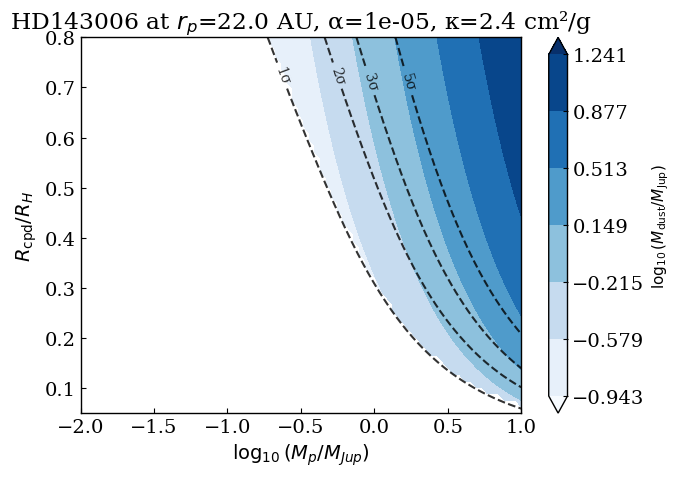

Calculating for Mp = 0.010 Mjup, Rout_frac = 0.050 -> RHill = 0.65 au
 The maximum tau for Rout  = 0 and is nan 
Calculating for Mp = 0.011 Mjup, Rout_frac = 0.050 -> RHill = 0.67 au
 The maximum tau for Rout  = 0 and is 2.289e+01 
Calculating for Mp = 0.012 Mjup, Rout_frac = 0.050 -> RHill = 0.69 au
 The maximum tau for Rout  = 0 and is 2.422e+01 
Calculating for Mp = 0.013 Mjup, Rout_frac = 0.050 -> RHill = 0.71 au
 The maximum tau for Rout  = 0 and is 2.560e+01 
Calculating for Mp = 0.014 Mjup, Rout_frac = 0.050 -> RHill = 0.73 au
 The maximum tau for Rout  = 0 and is 2.703e+01 
Calculating for Mp = 0.015 Mjup, Rout_frac = 0.050 -> RHill = 0.75 au
 The maximum tau for Rout  = 0 and is 2.851e+01 
Calculating for Mp = 0.017 Mjup, Rout_frac = 0.050 -> RHill = 0.77 au
 The maximum tau for Rout  = 0 and is 3.005e+01 
Calculating for Mp = 0.018 Mjup, Rout_frac = 0.050 -> RHill = 0.79 au
 The maximum tau for Rout  = 0 and is 3.163e+01 
Calculating for Mp = 0.020 Mjup, Rout_frac = 0.050 -> 

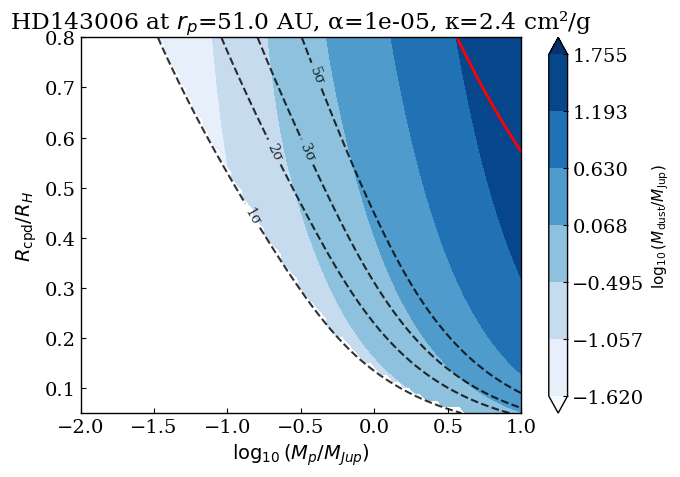

In [85]:
HD1423006_disk_arr = ["HD143006", 1.56, 167, 3.8, 0.226, 18.69, "15 58 36.913", "-22 57 15.221"]

HD1423006_target_flux_arr = [71, 79, 88, 97, 111, 220]  # mu Jy for different recovery fractions from 0.5 to 1.0

rD22 = 22 #140 * HD1423006_disk_arr[2] / 1000  # arcsec to au
rD51 = 51 #315* HD1423006_disk_arr[2] / 1000  # arcsec to au

# Run for the D22 gap
zhu_plots_flux_map(
    target_flux_arr=HD1423006_target_flux_arr,
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    lam_mm=1.25,
    alpha=1e-5,
    plotmass=True
)

# Run for the D51 gap
zhu_plots_flux_map(
    target_flux_arr=HD1423006_target_flux_arr,
    disk_arr=HD1423006_disk_arr,
    rp=rD51,
    lam_mm=1.25,
    alpha=1e-5,
    plotmass=True
)

note: difference between andrew and zhu
one is total disk mass, one not -> so the values are much larger

In [86]:
def compute_flux_map_zhu(
    target_flux_arr,
    disk_arr,
    rp=165,
    lam_mm=1.25,
    alpha=1e-3,
    y_min=0.05,
    y_max=0.8,
    verbose=False,
    x_min=-2.0,
    x_max=1.0
):
    """
    EXACT numerical replica of the original zhu_plots_flux_map() grid.
    Produces Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_vals identical to
    the internal arrays generated inside zhu_plots_flux_map().
    """

    # --- 1. Match OLD grid EXACTLY ---
    Mp_grid = np.logspace(x_min, x_max, 80)              # identical
    Rout_frac_grid = np.linspace(y_min, y_max, 60)  # identical
    M_star_jup = disk_arr[1] * 1047.56             # identical conversion

    # Output arrays – identical shapes
    Flux_vals = np.zeros((len(Rout_frac_grid), len(Mp_grid)))
    M_cpd_vals = np.zeros_like(Flux_vals)

    # --- 2. Compute the grid EXACTLY as old function did ---
    for i, frac in enumerate(Rout_frac_grid):
        for j, Mp in enumerate(Mp_grid):

            # Hill radius: identical
            RHill = rp * (Mp / (3 * M_star_jup))**(1/3)

            # Rout = frac * RHill: identical
            Rout = frac * RHill

            # identical call signature — nothing changed
            out = calculate_disk_properties_zhu(
                M_star = disk_arr[1],
                Mp = Mp,
                Mdot = Mp * 1e-6,       # EXACT BEHAVIOR from old code
                alpha = alpha,
                rp = rp,
                d_pc = disk_arr[2],
                lam_mm = lam_mm,
                T_ISM = 10.0,
                Lstar = disk_arr[3],
                Rout = Rout
            )

            # identical assignments
            Flux_vals[i, j] = out["F_nu_tot"]
            M_cpd_vals[i, j] = out["M_dust"]

            if verbose:
                print(f"[ZHU] i={i}, j={j}, Mp={Mp:.3f}, frac={frac:.3f}, Flux={out['F_nu_tot']:.3f}")

    return Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_vals



In [87]:
def plot_flux_map_zhu(
    Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_vals,
    disk_arr,
    target_flux_arr,
    rp=165,
    lam_mm=1.25,
    alpha=1e-3,
    plotmass=True,
    color='Spectral',
    y_min=0.05,
    y_max=0.8,
    x_min=None,
    x_max=None,
    sigma_ujy = None,
    detection_sigma=None,
    ax=None

):
    """
    EXACT plotting equivalent of zhu_plots_flux_map(), but using
    precomputed grids (Mp, Rout_frac, Flux_vals, M_cpd_vals).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    # -----------------------------
    # 1. Masking identical to old code
    # -----------------------------
    min_flux = sigma_ujy
    masked_Flux_vals = np.where(Flux_vals >= min_flux, Flux_vals, np.nan)
    masked_M_dust = np.where(Flux_vals >= min_flux, M_cpd_vals, np.nan)

    sigma_levels = [3, 5]
    flux_levels = [n * sigma_ujy for n in sigma_levels]

    # -----------------------------
    # 2. Set up plot
    # -----------------------------

    if color == '5sigsource':
        cmap = 'Blues'
    elif color == 'planet':
        cmap = 'Greens'
    elif color == 'external':
        cmap = 'Purples'
    else:
        cmap = color

    # -----------------------------
    # 3. Filled contours (mass or flux)
    # -----------------------------
    if plotmass:
        vmin = np.nanmin(np.log10(masked_M_dust))
        vmax = np.nanmax(np.log10(masked_M_dust))

        cf = ax.contourf(
            np.log10(Mp_grid), Rout_frac_grid, np.log10(masked_M_dust),
            levels=np.linspace(vmin, vmax, 9),
            cmap=cmap, extend='both'
        )
        #cbar = plt.colorbar(cf, ax=ax)
        #cbar.set_label(r'$\log_{10}(M_{\rm dust}/M_{\rm Jup})$', fontsize=11)

    else:
        cf = ax.contourf(
            np.log10(Mp_grid), Rout_frac_grid, Flux_vals,
            levels=flux_levels, cmap=cmap, extend='both'
        )
        #cbar = plt.colorbar(cf, ax=ax)
        #cbar.set_label(r'$F_\nu\, [\mu{\rm Jy}]$', fontsize=11)

    # -----------------------------
    # 4. Sigma contours (1σ,2σ,3σ,5σ)
    # -----------------------------
    cs = ax.contour(
        np.log10(Mp_grid), Rout_frac_grid, Flux_vals,
        levels=flux_levels, colors='grey',
        linewidths=1.5, linestyles='dashed', alpha=0.8
    )

    # Label contours
    labels = [f'{n}σ' for n in sigma_levels]
    fmt = {level: label for level, label in zip(flux_levels, labels)}
    ax.clabel(cs, fmt=fmt, fontsize=10, inline=True)

    # -----------------------------
    # 5. ALMA beam limit (same as old)
    # -----------------------------
    M_star_jup = disk_arr[1] * 1047.56
    RHill_arr = rp * (Mp_grid / (3 * M_star_jup))**(1/3)
    Rout_frac_beam = 7.4 / (2 * RHill_arr)    # identical to old

    # Compute beam limit
    RHill_arr = rp * (Mp_grid / (3 * M_star_jup))**(1/3)
    res_au = disk_arr[4] * disk_arr[2]  # beam size times distance
    Rout_frac_beam = res_au / (2 * RHill_arr)
    
    
    ax.plot(
        np.log10(Mp_grid), Rout_frac_beam,
        color='purple', linestyle='-.', lw=3, label='ALMA resolution limit'
    )

    # -----------------------------
    # 6. Axes labels, limits, title
    # -----------------------------
    ax.set_xlabel(r"$\log_{10}(M_p/M_{Jup})$")
    ax.set_ylabel(r"$R_{\rm cpd}/R_H$")
    ax.set_ylim(y_min, y_max)
    if x_min is not None and x_max is not None:
        ax.set_xlim(x_min, x_max)
    ax.set_title(
        f"{disk_arr[0]} at $r_p$={rp:.1f} AU"
    )

    # ------------------------------------------------
    # 7. Plot detection simga line
    # -----------------------------------------------
    if detection_sigma is not None:
        detection_level = detection_sigma * sigma_ujy
        cs = ax.contour(
            np.log10(Mp_grid), Rout_frac_grid, Flux_vals,
            levels=[detection_level], colors='black',
            linewidths=2, linestyles='solid', alpha=0.9
        )
        fmt = {detection_level: f'{detection_sigma}σ'}
        ax.clabel(cs, fmt=fmt, fontsize=12, inline=True)

    return cf

C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\55144008.py:41: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet / (4*np.pi*sigmaB*R**2))**0.25
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\55144008.py:139: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


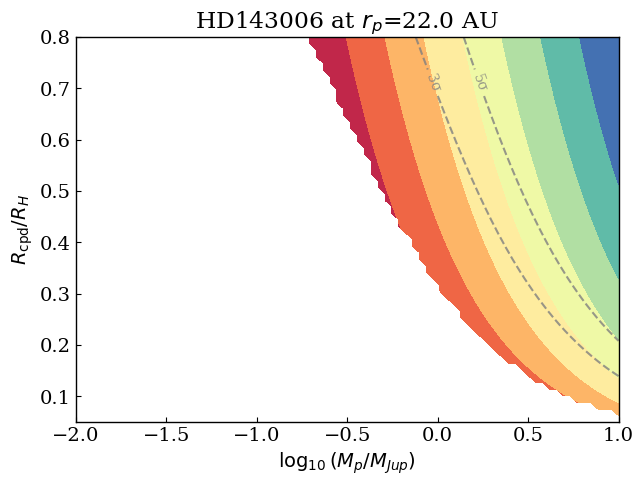

In [88]:
# Compute grid (numerically identical)
Mp, Rout, Flux, Mcpd = compute_flux_map_zhu(
    target_flux_arr=HD1423006_target_flux_arr,
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    lam_mm=1.25,
    alpha=1e-5
)

# Plot identical look as old zhu_plots_flux_map()
plot_flux_map_zhu(
    Mp_grid=Mp,
    Rout_frac_grid=Rout,
    Flux_vals=Flux,
    M_cpd_vals=Mcpd,
    disk_arr=HD1423006_disk_arr,
    target_flux_arr=HD1423006_target_flux_arr,
    rp=rD22,
    lam_mm=1.25,
    alpha=1e-5,
    plotmass=True,
    sigma_ujy=HD1423006_target_flux_arr[0]
)


C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\55144008.py:41: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet / (4*np.pi*sigmaB*R**2))**0.25
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\55144008.py:139: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


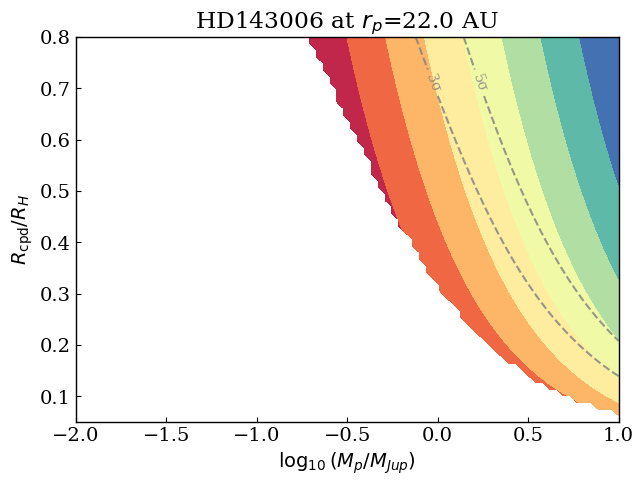

In [89]:
# Compute grid (numerically identical)
Mpvis, Routvis, Fluxvis, Mcpdvis = compute_flux_map_zhu(
    target_flux_arr=HD1423006_target_flux_arr,
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    lam_mm=1.25,
    alpha=1e-7
)

# Plot identical look as old zhu_plots_flux_map()
plot_flux_map_zhu(
    Mp_grid=Mpvis,
    Rout_frac_grid=Routvis,
    Flux_vals=Fluxvis,
    M_cpd_vals=Mcpdvis,
    disk_arr=HD1423006_disk_arr,
    target_flux_arr=HD1423006_target_flux_arr,
    rp=rD22,
    lam_mm=1.25,
    alpha=1e-7,
    plotmass=True,
    sigma_ujy=HD1423006_target_flux_arr[0]
)

In [90]:
from scipy.interpolate import griddata

def plot_flux_Mcpd_Routfrac_contour(
    Mp_grid,
    Rout_frac_grid,
    Flux_vals,
    M_cpd_vals,
    Mp_fixed=1.0,
    disk_arr=None,
    rp=None,
    alpha=1e-3,
    cmap="inferno",
    log_flux=True,
    n_interp=200
):
    """
    Creates a contourf plot of Flux on the (Mcpd, Rout_frac) plane
    for a single fixed planet mass Mp_fixed.

    x-axis: Mcpd [Earth masses]
    y-axis: Rcpd / RHill
    color: Flux (or log10 Flux)
    """

    # 1. Find the nearest planet mass
    j = np.argmin(np.abs(Mp_grid - Mp_fixed))

    # 2. Extract 1D arrays for this Mp
    Mcpd_1D = M_cpd_vals[:, j]             # shape (N_Rout,)
    Flux_1D = Flux_vals[:, j]              # shape (N_Rout,)
    Rout_1D = Rout_frac_grid               # shape (N_Rout,)

    # 3. Convert Mcpd to Mearth
    Mcpd_Earth = Mcpd_1D * 317.8

    # Mask invalid
    #valid = (Flux_1D > 0) & (~np.isnan(Flux_1D)) & (~np.isnan(Mcpd_Earth))
    #Mcpd_Earth = Mcpd_Earth[valid]
    #Rout_1D = Rout_1D[valid]
    #Flux_1D = Flux_1D[valid]

    # --- 4. Interpolate onto a regular 2D grid for contourf ---
    x = Mcpd_Earth
    y = Rout_1D
    z = np.log10(Flux_1D) if log_flux else Flux_1D

    # Define grid
    xi = np.linspace(min(x), max(x), n_interp)
    yi = np.linspace(min(y), max(y), n_interp)
    Xi, Yi = np.meshgrid(xi, yi)

    Zi = griddata((x, y), z, (Xi, Yi), method='linear')

    # --- 5. Plot ---
    fig, ax = plt.subplots(figsize=(7, 5))

    cf = ax.contourf(
        Xi, Yi, Zi,
        levels=20,
        cmap=cmap
    )

    cbar = plt.colorbar(cf, ax=ax)
    if log_flux:
        cbar.set_label(r"$\log_{10} F_\nu\ [{\rm \mu Jy}]$")
    else:
        cbar.set_label(r"$F_\nu\ [{\rm \mu Jy}]$")

    ax.set_xlabel(r"$M_{\rm cpd}\ [{\rm M}_\oplus]$")
    ax.set_ylabel(r"$R_{\rm cpd}/R_H$")
    ax.set_title(
        f"Flux map in (Mcpd, Rcpd/RH) for Mp={Mp_fixed} Mjup\n"
        f"{disk_arr[0]} at rp={rp} AU, α={alpha}"
        if disk_arr and rp else
        f"Flux map for Mp={Mp_fixed} Mjup"
    )

    plt.tight_layout()
    plt.show()

    return Xi, Yi, Zi


C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\55144008.py:41: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet / (4*np.pi*sigmaB*R**2))**0.25
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\55144008.py:139: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


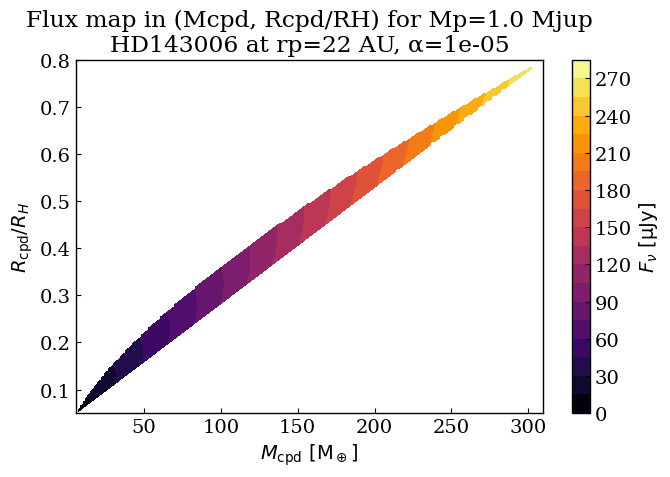

(array([[  5.88732403,   7.41304917,   8.93877432, ..., 306.45517816,
         307.98090331, 309.50662846],
        [  5.88732403,   7.41304917,   8.93877432, ..., 306.45517816,
         307.98090331, 309.50662846],
        [  5.88732403,   7.41304917,   8.93877432, ..., 306.45517816,
         307.98090331, 309.50662846],
        ...,
        [  5.88732403,   7.41304917,   8.93877432, ..., 306.45517816,
         307.98090331, 309.50662846],
        [  5.88732403,   7.41304917,   8.93877432, ..., 306.45517816,
         307.98090331, 309.50662846],
        [  5.88732403,   7.41304917,   8.93877432, ..., 306.45517816,
         307.98090331, 309.50662846]]),
 array([[0.05      , 0.05      , 0.05      , ..., 0.05      , 0.05      ,
         0.05      ],
        [0.05376884, 0.05376884, 0.05376884, ..., 0.05376884, 0.05376884,
         0.05376884],
        [0.05753769, 0.05753769, 0.05753769, ..., 0.05753769, 0.05753769,
         0.05753769],
        ...,
        [0.79246231, 0.79246231, 0.7

In [91]:
Mp, Rout, Flux, Mcpd = compute_flux_map_zhu(
    target_flux_arr=HD1423006_target_flux_arr,
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    lam_mm=1.25,
    alpha=1e-5
)

plot_flux_Mcpd_Routfrac_contour(
    Mp_grid=Mp,
    Rout_frac_grid=Rout,
    Flux_vals=Flux,
    M_cpd_vals=Mcpd,
    Mp_fixed=1.0,
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    alpha=1e-5,
    log_flux=False
)


In [92]:
def compute_flux_map_zhu_MpMdot(
    disk_arr,
    rp=165,
    Rout_frac=0.3,
    lam_mm=1.25,
    alpha=1e-3,
    Mp_min=-2, Mp_max=1, n_Mp=40,
    Mdot_min=-9, Mdot_max=-4, n_Mdot=40,
    verbose=True
):
    """
    Compute Zhu flux map in the (Mp, Mdot) plane
    with a fixed Rout/RH = constant.

    Returns:
        Mp_grid (n_Mp)
        Mdot_grid (n_Mdot)
        Flux_map (n_Mdot, n_Mp)     ← flux at each (Mdot, Mp)
        Q_map = Mp * Mdot
    """
    Mp_grid = np.logspace(Mp_min, Mp_max, n_Mp)
    Mdot_grid = np.logspace(Mdot_min, Mdot_max, n_Mdot)

    Flux_map = np.zeros((n_Mdot, n_Mp))
    Q_map = np.zeros_like(Flux_map)

    M_star_jup = disk_arr[1] * 1047.56

    for j, Mp in enumerate(Mp_grid):
        RHill = rp * (Mp / (3 * M_star_jup))**(1/3)
        Rout = Rout_frac * RHill

        for i, Mdot in enumerate(Mdot_grid):

            out = calculate_disk_properties_zhu(
                M_star=disk_arr[1],
                Mp=Mp,
                Mdot=Mdot,
                alpha=alpha,
                rp=rp,
                d_pc=disk_arr[2],
                lam_mm=lam_mm,
                T_ISM=10.0,
                Lstar=disk_arr[3],
                Rout=Rout
            )

            Flux_map[i,j] = out["F_nu_tot"]
            Q_map[i,j] = Mp * Mdot

            if verbose and (i % 10 == 0 and j % 10 == 0):
                print(f"Mp={Mp:.3f}, Mdot={Mdot:.2e}, Flux={out['F_nu_tot']:.3f}")

    return Mp_grid, Mdot_grid, Flux_map, Q_map


In [93]:
def plot_zhu_Mp_Mdot_flux(
    Mp_grid, Mdot_grid, Flux_vals,
    disk_arr, rp, alpha,
    target_flux_arr,
    ax=None
):
    import numpy as np
    import matplotlib.pyplot as plt

    logMp = np.log10(Mp_grid)
    logMdot = np.log10(Mdot_grid)
    LOGMP, LOGMDOT = np.meshgrid(logMp, logMdot)
    Q = Mp_grid[None, :] * Mdot_grid[:, None]
    logQ = np.log10(Q)
    min_flux = min(target_flux_arr)
    Flux_masked = np.where(Flux_vals >= min_flux, Flux_vals, np.nan)
    logFlux = np.log10(Flux_masked)

    # 1. Create axis if needed
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    else:
        fig = None

    # 2. Main contourf
    cf = ax.contourf(
        LOGMP, LOGMDOT, logFlux,
        levels=8,
        cmap="Spectral",
        extend="both"
    )
    if fig is not None:
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r"$\log_{10}(F_\nu\, [\mu{\rm Jy}])$", fontsize=12)

    # 3. Q contours
    Q_levels = np.linspace(logQ.min()+0.5, logQ.max()-0.5, 5)
    cq = ax.contour(
        LOGMP, LOGMDOT, logQ,
        levels=Q_levels,
        colors="cyan",
        linestyles="dashed",
        linewidths=1.2
    )
    ax.clabel(cq, fmt=lambda x: f"Q={10**x:.1e}", fontsize=9)

    # 4. Sigma detection contours
    sigma_ujy = target_flux_arr[0]
    sigma_levels = [1, 2, 3, 5 , 10]
    flux_levels = [n * sigma_ujy for n in sigma_levels]
    cs = ax.contour(
        LOGMP, LOGMDOT, Flux_vals,
        levels=flux_levels,
        colors="white",
        linestyles="dashed",
        linewidths=1.6
    )
    ax.clabel(cs, fmt={lvl: f"{n}σ" for lvl, n in zip(flux_levels, sigma_levels)}, fontsize=10)

    # 5. Axis formatting
    ax.set_xlabel(r"$\log_{10}(M_p/M_{\rm Jup})$", fontsize=12)
    ax.set_ylabel(r"$\log_{10}(\dot{M}\,[M_{\rm Jup}\,{\rm yr}^{-1}])$", fontsize=12)
    ax.set_title(
        rf"Zhu Model: {disk_arr[0]} at $r_p={rp}$ AU, $\alpha={alpha}$",
        fontsize=14
    )

    # 6. Regime boundaries
    Rfrac = 0.3
    M_star_jup = disk_arr[1] * 1047.56
    R_matrix = np.zeros_like(Flux_vals)
    for i, Mp in enumerate(Mp_grid):
        RHill = rp * (Mp / (3 * M_star_jup))**(1/3)
        Rcpd = Rfrac * RHill * AU
        R_matrix[i,:] = Rcpd

    T_visc = np.zeros_like(Flux_vals)
    T_pirr = np.zeros_like(Flux_vals)
    T_sirr = np.zeros_like(Flux_vals)
    for i, Mp in enumerate(Mp_grid):
        for j, Mdot in enumerate(Mdot_grid):
            R = R_matrix[i,j]
            Lp = Lp_from_Mp(Mp) * L_sun
            T_visc[i,j] = (3*G*(Mp*M_jup)*(Mdot*M_jup/sec_per_yr) /
                            (8*np.pi*sigmaB*R**3))**0.25
            T_pirr[i,j] = (0.1 * Lp / (4*np.pi*sigmaB*R**2))**0.25
            Lstar = disk_arr[3] * L_sun
            T_sirr[i,j] = (0.02 * Lstar / (8*np.pi*sigmaB*(rp*AU)**2))**0.25

    regime_index = np.argmax(np.stack([T_visc, T_pirr, T_sirr]), axis=0)
    logMp_grid, logMdot_grid = np.meshgrid(logMp, logMdot)
    ax.contour(
        logMp_grid, logMdot_grid, regime_index.T,
        levels=[0.5, 1.5], colors="pink", linewidths=1.5
    )
    ax.text(-0.8, -5.2, "viscous heating", color="pink", fontsize=12)
    ax.text( 0.4, -8.0, "planet irradiation", color="pink", fontsize=12)
    ax.text(-1.8, -7.5, "stellar irradiation", color="pink", fontsize=12)

    if fig is not None:
        plt.tight_layout()
        plt.show()

In [94]:
# Mp and Mpdot become degenerate when the disc is optically thin or irradiation dominated   
# Can also plot MpMdot against Rout/Rhill (mp dependent)

C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\55144008.py:139: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


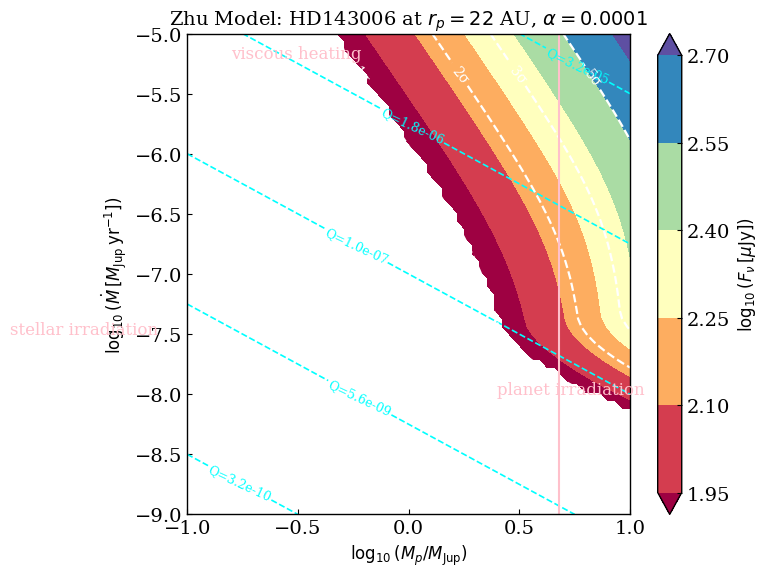

In [95]:
# 1. Build Mp–Mdot grid
Mp_grid = np.logspace(-1, 1, 60)       # 0.1–10 Mjup
Mdot_grid = np.logspace(-9, -5, 60)    # 1e-9 – 1e-5 Mjup/yr

# 2. Compute flux for a fixed Rout/RH (e.g., 0.3)
Flux_vals = np.zeros((len(Mdot_grid), len(Mp_grid)))
for i, Mdot in enumerate(Mdot_grid):
    for j, Mp in enumerate(Mp_grid):

        RHill = rD22 * (Mp / (3 * 1047.56 * HD1423006_disk_arr[1]))**(1/3)
        Rout = 0.3 * RHill

        out = calculate_disk_properties_zhu(
            M_star = HD1423006_disk_arr[1],
            Mp = Mp,
            Mdot = Mdot,
            alpha = 1e-4,
            rp = rD22,
            d_pc = HD1423006_disk_arr[2],
            lam_mm = 1.25,
            Rout = Rout,
            Lstar = HD1423006_disk_arr[3],
        )

        Flux_vals[i, j] = out["F_nu_tot"]

# 3. Plot
plot_zhu_Mp_Mdot_flux(
    Mp_grid, Mdot_grid, Flux_vals,
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    alpha=1e-4,
    target_flux_arr=HD1423006_target_flux_arr
)


C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\55144008.py:139: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


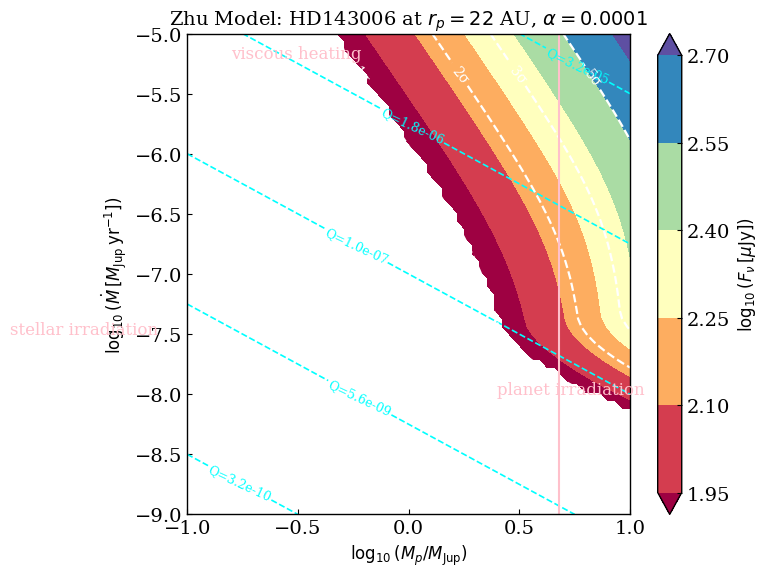

In [96]:
# 1. Build Mp–Mdot grid
Mp_grid = np.logspace(-1, 1, 60)       # 0.1–10 Mjup
Mdot_grid = np.logspace(-9, -5, 60)    # 1e-9 – 1e-5 Mjup/yr

# 2. Compute flux for a fixed Rout/RH (e.g., 0.3)
Flux_vals = np.zeros((len(Mdot_grid), len(Mp_grid)))
for i, Mdot in enumerate(Mdot_grid):
    for j, Mp in enumerate(Mp_grid):

        RHill = rD22 * (Mp / (3 * 1047.56 * HD1423006_disk_arr[1]))**(1/3)
        Rout = 0.3 * RHill

        out = calculate_disk_properties_zhu(
            M_star = HD1423006_disk_arr[1],
            Mp = Mp,
            Mdot = Mdot,
            alpha = 1e-4,
            rp = rD22,
            d_pc = HD1423006_disk_arr[2],
            lam_mm = 1.25,
            Rout = Rout,
            Lstar = HD1423006_disk_arr[3],
        )

        Flux_vals[i, j] = out["F_nu_tot"]

# 3. Plot
plot_zhu_Mp_Mdot_flux(
    Mp_grid, Mdot_grid, Flux_vals,
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    alpha=1e-4,
    target_flux_arr=HD1423006_target_flux_arr
)


C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


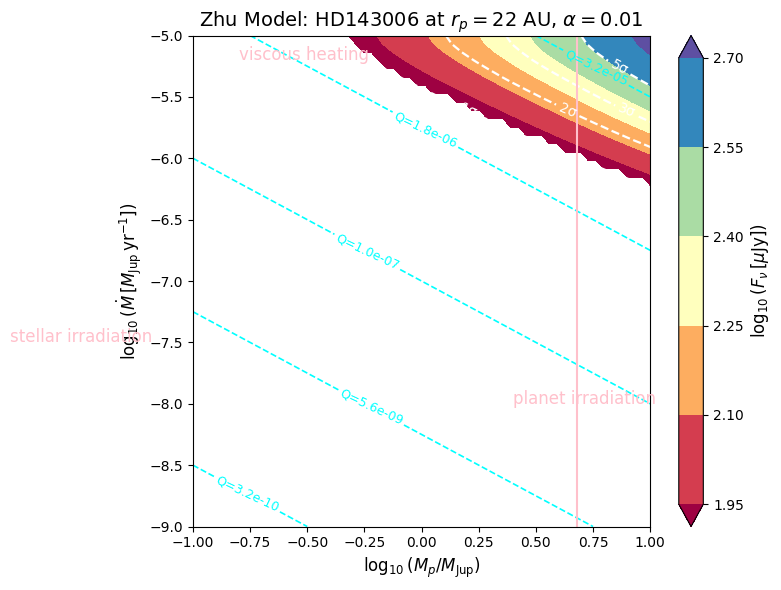

In [21]:
# 2. Compute flux for a fixed Rout/RH (e.g., 0.3)
Flux_vals = np.zeros((len(Mdot_grid), len(Mp_grid)))
for i, Mdot in enumerate(Mdot_grid):
    for j, Mp in enumerate(Mp_grid):

        RHill = rD22 * (Mp / (3 * 1047.56 * HD1423006_disk_arr[1]))**(1/3)
        Rout = 0.3 * RHill

        out = calculate_disk_properties_zhu(
            M_star = HD1423006_disk_arr[1],
            Mp = Mp,
            Mdot = Mdot,
            alpha = 1e-2,
            rp = rD22,
            d_pc = HD1423006_disk_arr[2],
            lam_mm = 1.25,
            Rout = Rout,
            Lstar = HD1423006_disk_arr[3],
        )

        Flux_vals[i, j] = out["F_nu_tot"]

# 3. Plot
plot_zhu_Mp_Mdot_flux(
    Mp_grid, Mdot_grid, Flux_vals,
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    alpha=1e-2,
    target_flux_arr=HD1423006_target_flux_arr
)


Define the plotting function

### Plot for 5 sigma sources

In [22]:
# Extend it to ALMA disks
 # name, Mstar (Msun), d_pc, Lstar (Lsun), Fnu (muJy), inc (deg)
disk_arr = {
    "AA_Tau":      ["AA_Tau", 0.79, 145, 1.1, 0.12, 58.54, "04 34 55.420", "+24 28 53.034"],
    "CQ_Tau":      ["CQ_Tau", 1.4, 149, 10, 0.135, 35.24, "05 35 58.467", "+24 44 54.091"],
    "DM_Tau":      ["DM_Tau", 0.45, 144, 0.24, 0.134, 35.97, "04 33 48.733", "+18 10 09.973"],
    "HD_34282":    ["HD_34282", 1.61, 309, 108, 0.106, 59.09, "05 16 00.477", "-09 48 35.394"],
    "HD_135344B":  ["HD_135344B", 1.61, 135, 6.7, 0.26, 20.73, "15 15 48.446", "-37 09 16.024"],
    "HD_143006":   ["HD_143006", 1.56, 167, 3.8, 0.226, 18.69, "15 58 36.913", "-22 57 15.221"],
    "J1604":       ["J1604", 1.29, 112, 0.76, 0.257, 8.72, "16 04 21.642", "-21 30 29.058"],
    "J1615":       ["J1615", 1.14, 156, 1.07, 0.303, 47.10, "16 15 20.234", "-32 55 05.099"],
    "J1842":       ["J1842", 1.07, 151, 0.8, 0.235, 39.22, "18 42 57.981", "-35 32 42.827"],
    "J1852":       ["J1852", 1.03, 147, 0.6, 0.236, 32.50, "18 52 17.301", "-37 00 11.949"],
    "LkCa_15":     ["LkCa_15", 1.14, 156, 1, 0.131, 50.59, "04 39 17.791", "+22 21 03.390"],
    "MWC_758":     ["MWC_758", 1.4, 151, 10.4, 0.241, 7.27, "05 30 27.529", "+25 19 57.076"],
    "PDS_66":      ["PDS_66", 1.28, 98, 1.2, 0.234, 32.02, "13 22 07.542", "-69 38 12.219"],
    "SY_Cha":      ["SY_Cha", 0.77, 182, 0.55, 0.178, 51.65, "10 56 30.388", "-77 11 39.402"],
    "V4046_Sgr":   ["V4046_Sgr", 1.73, 72, 0.5, 0.241, 33.36, "18 14 10.482", "-32 47 34.517"],
}




five_sigma_sources = [
    # Format: [disk_name, radius_au, flux_ujy, sigma_flux_ujy, PB , detection sigma]
    ["CQ_Tau", 165.37, 260.30, 45.81 , 0.99, 5.08],
    ["CQ_Tau", 932.14, 1455, 40.25,0.76, 5.46],
    ["DM_Tau", 1845.47, 5422.67, 161.82, 0.36, 9.46 ],
    ["V4046_Sgr", 837.63, 90.54,22.22, 0.42, 5.24],
]


# Planet kink 

kink_sources = [
    # Format: [disk_name, radius_au, sigma_flux]
    ["AA_Tau", 80, 136.85],
    ["SY_Cha", 140, 57.23],
    ["J1842", 105, 35.29],
    ["J1615", 310, 24.56],
    ["LkCa_15", 240, 20.14],
    ["HD_143006", 32, 896.96],
]



In [23]:
with open("disk_arr.pkl", "wb") as f:
    pickle.dump(disk_arr, f)

C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:41: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet / (4*np.pi*sigmaB*R**2))**0.25
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


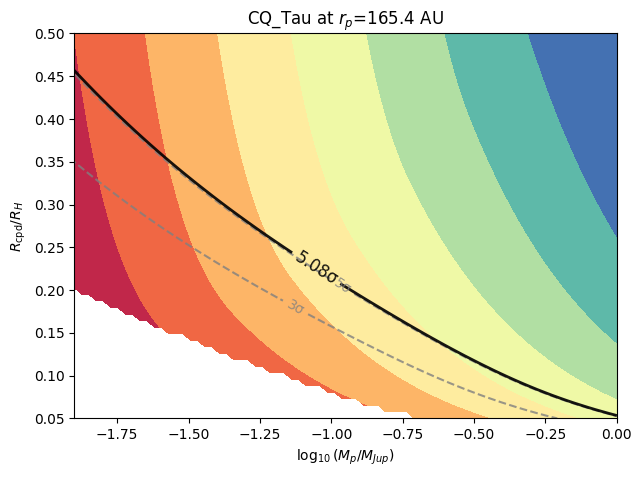

In [24]:
#### CQ Tau at 165 au

disk_name, radius_au, flux_ujy, sigma_flux_ujy, PB, detection_sigma = five_sigma_sources[0]
Mp_grid_CQTau165, Rout_frac_grid_CQTau165, Flux_vals_CQTau165, M_cpd_chosen_CQTau165 = compute_flux_map_zhu(
        target_flux_arr=[sigma_flux_ujy*PB*detection_sigma],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_mm=0.9,
        y_min =0.05,
        y_max=0.5,
        x_min=-2.0,
        x_max=0,
        alpha=1e-6
        )


# Plot identical look as old zhu_plots_flux_map()
plot_flux_map_zhu(
    Mp_grid=Mp_grid_CQTau165,
    Rout_frac_grid=Rout_frac_grid_CQTau165,
    Flux_vals=Flux_vals_CQTau165,
    M_cpd_vals=M_cpd_chosen_CQTau165,
    disk_arr=disk_arr['CQ_Tau'],
    target_flux_arr=disk_arr['CQ_Tau'],
    rp= five_sigma_sources[0][1],
    lam_mm=0.9,
    alpha=1e-6,
    sigma_ujy=five_sigma_sources[0][3],
    plotmass=True,
    y_min=0.05,
    y_max=0.5,
    x_min=-1.9,
    x_max=0,
    detection_sigma=five_sigma_sources[0][5]
)







C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:41: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet / (4*np.pi*sigmaB*R**2))**0.25
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


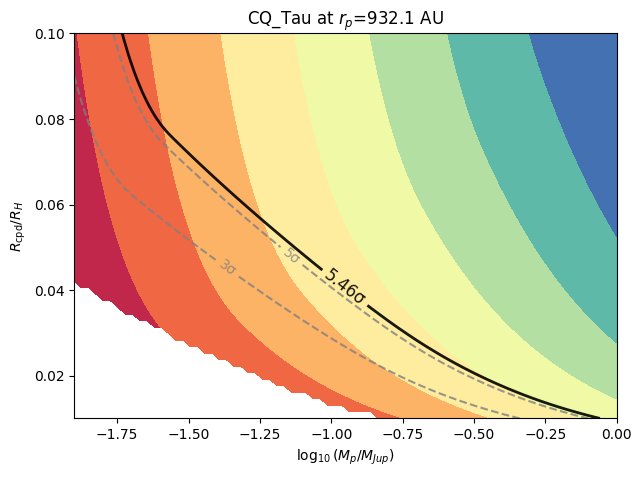

In [25]:
#### CQ Tau at 932 au

disk_name, radius_au, flux_ujy, sigma_flux_ujy, PB, detection_sigma = five_sigma_sources[1]
Mp_grid_CQTau932, Rout_frac_grid_CQTau932, Flux_vals_CQTau932, M_cpd_chosen_CQTau932 = compute_flux_map_zhu(
        target_flux_arr=[sigma_flux_ujy*PB*detection_sigma],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_mm=0.9,
        y_min =0.01,
        y_max=0.1,
        x_min=-2.0,
        x_max=0,
        alpha=1e-5
        )


# Plotfor 932
plot_flux_map_zhu(
    Mp_grid=Mp_grid_CQTau932,
    Rout_frac_grid=Rout_frac_grid_CQTau932,
    Flux_vals=Flux_vals_CQTau932,
    M_cpd_vals=M_cpd_chosen_CQTau932,
    disk_arr=disk_arr['CQ_Tau'],
    target_flux_arr=disk_arr['CQ_Tau'],
    rp= five_sigma_sources[1][1],
    lam_mm=0.9,
    alpha=1e-5,
    sigma_ujy=five_sigma_sources[1][3],
    plotmass=True,
    y_min=0.01,
    y_max=0.1,
    x_min=-1.9,
    x_max=0,
    detection_sigma=five_sigma_sources[1][5]
)







C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:41: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet / (4*np.pi*sigmaB*R**2))**0.25
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


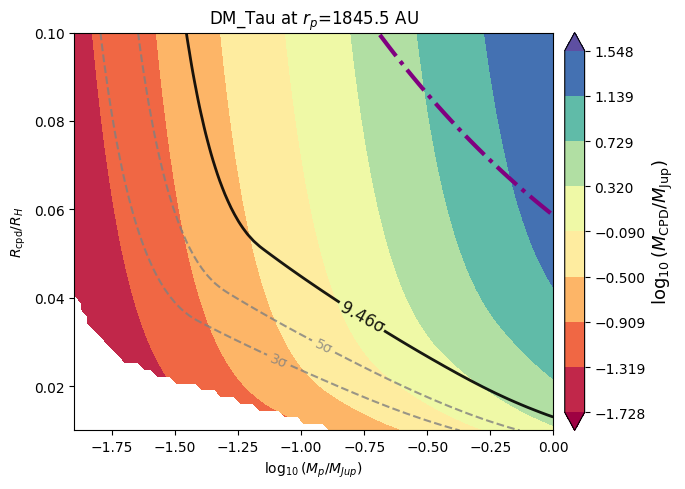

In [26]:
# DM Tau at 1845 au

disk_name, radius_au, flux_ujy, sigma_flux_ujy, PB, detection_sigma = five_sigma_sources[2]
Mp_grid_DMTau1845, Rout_frac_grid_DMTau1845, Flux_vals_DMTau1845, M_cpd_chosen_DMTau1845 = compute_flux_map_zhu(
        target_flux_arr=[sigma_flux_ujy*PB*detection_sigma],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_mm=0.9,
        y_min =0.01,
        y_max=0.1,
        x_min=-2.0,
        x_max=0,
        alpha=1e-5
        )
# Plotfor 1845
cf = plot_flux_map_zhu(
    Mp_grid=Mp_grid_DMTau1845,
    Rout_frac_grid=Rout_frac_grid_DMTau1845,
    Flux_vals=Flux_vals_DMTau1845,
    M_cpd_vals=M_cpd_chosen_DMTau1845,
    disk_arr=disk_arr['DM_Tau'],
    target_flux_arr=disk_arr['DM_Tau'],
    rp= five_sigma_sources[2][1],
    lam_mm=0.9,
    alpha=1e-5,
    sigma_ujy=five_sigma_sources[2][3],
    plotmass=True,
    y_min=0.01,
    y_max=0.1,
    x_min=-1.9,
    x_max=0,
    detection_sigma=five_sigma_sources[2][5]
)

plt.colorbar(cf, orientation="vertical", pad=0.02).set_label(
    r"$\log_{10}(M_{\rm CPD}/M_{\rm Jup})$", fontsize=13
)
plt.tight_layout()
plt.show()


C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:41: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet / (4*np.pi*sigmaB*R**2))**0.25
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


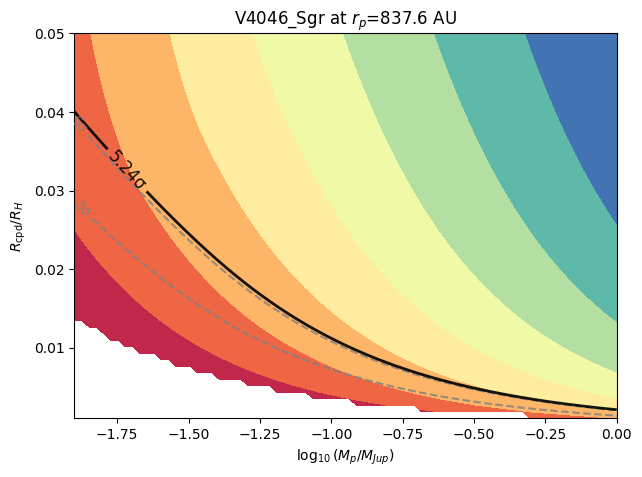

In [27]:
# Plot for V4046 Sgr at 837 au
disk_name, radius_au, flux_ujy, sigma_flux_ujy, PB, detection_sigma = five_sigma_sources[3]
Mp_grid_V4046Sgr837, Rout_frac_grid_V4046Sgr837, Flux_vals_V4046Sgr837, M_cpd_chosen_V4046Sgr837 = compute_flux_map_zhu(
        target_flux_arr=[sigma_flux_ujy*PB*detection_sigma],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_mm=0.9,
        y_min =0.001,
        y_max=0.05,
        x_min=-2.0,
        x_max=0,
        alpha=1e-5
        )
# Plotfor 837
plot_flux_map_zhu(
    Mp_grid=Mp_grid_V4046Sgr837,
    Rout_frac_grid=Rout_frac_grid_V4046Sgr837,
    Flux_vals=Flux_vals_V4046Sgr837,
    M_cpd_vals=M_cpd_chosen_V4046Sgr837,
    disk_arr=disk_arr['V4046_Sgr'],
    target_flux_arr=disk_arr['V4046_Sgr'],
    rp= five_sigma_sources[3][1],
    lam_mm=0.9,
    alpha=1e-5,
    sigma_ujy=five_sigma_sources[3][3],
    plotmass=True,
    y_min=0.001,
    y_max=0.05,
    x_min=-1.9,
    x_max=0,
    detection_sigma=five_sigma_sources[3][5]
)

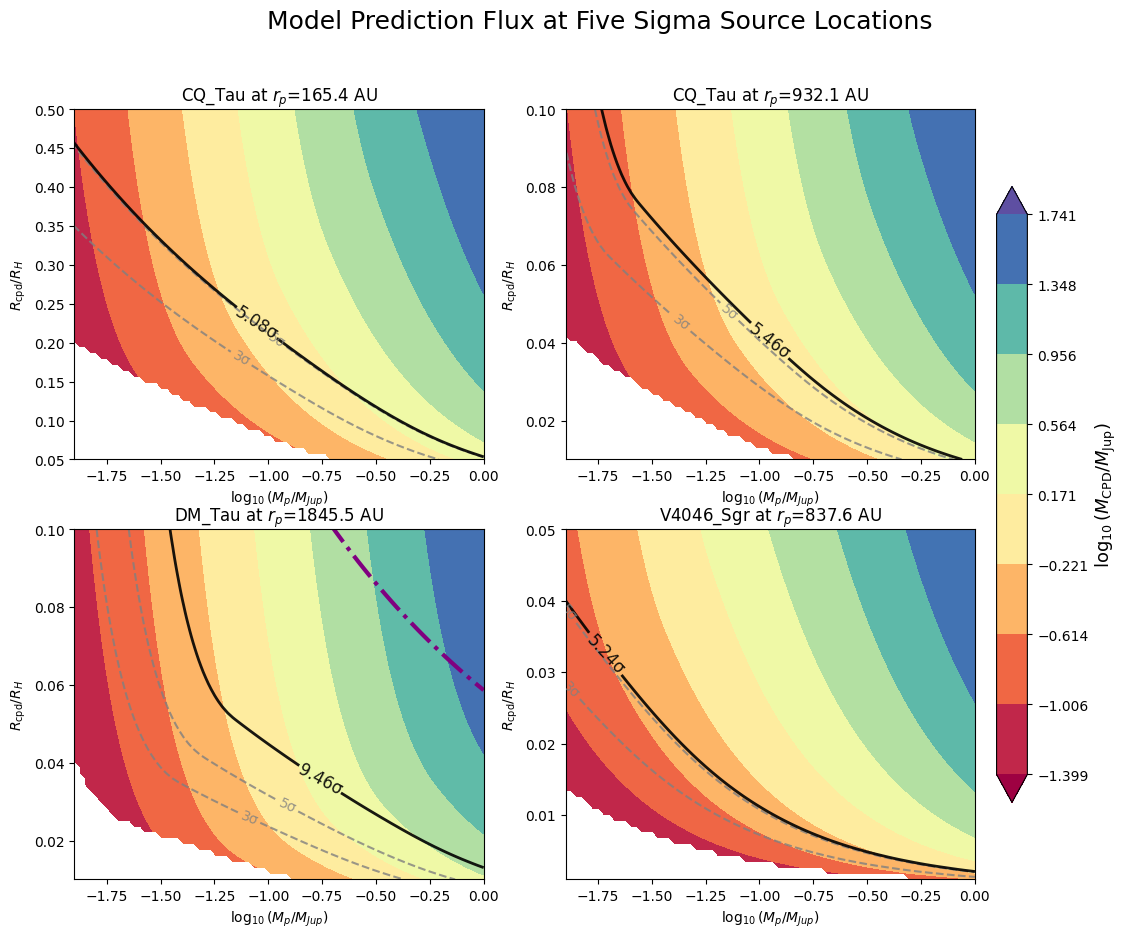

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Map source index to five_sigma_sources for rp lookup
source_configs = [
    {"idx": 0, "Mp_grid": Mp_grid_CQTau165, "Rout_frac_grid": Rout_frac_grid_CQTau165,
     "M_cpd_chosen": M_cpd_chosen_CQTau165, "title": "CQ Tau, r = 165 au", "y_lim": (0.05, 0.5), "x_lim": (-1.9, 0)},
    {"idx": 1, "Mp_grid": Mp_grid_CQTau932, "Rout_frac_grid": Rout_frac_grid_CQTau932,
     "M_cpd_chosen": M_cpd_chosen_CQTau932, "title": "CQ Tau, r = 932 au", "y_lim": (0.01, 0.1), "x_lim": (-1.9, 0)},
    {"idx": 2, "Mp_grid": Mp_grid_DMTau1845, "Rout_frac_grid": Rout_frac_grid_DMTau1845,
     "M_cpd_chosen": M_cpd_chosen_DMTau1845, "title": "DM Tau, r = 1845 au", "y_lim": (0.01, 0.1), "x_lim": (-1.9, 0)},
    {"idx": 3, "Mp_grid": Mp_grid_V4046Sgr837, "Rout_frac_grid": Rout_frac_grid_V4046Sgr837,
     "M_cpd_chosen": M_cpd_chosen_V4046Sgr837, "title": "V4046 Sgr, r = 837 au", "y_lim": (0.001, 0.05), "x_lim": (-1.9, 0)},
]

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
cf_list = []

for i, cfg in enumerate(source_configs):
    disk_name = five_sigma_sources[cfg["idx"]][0]
    rp = five_sigma_sources[cfg["idx"]][1]
    sigma_ujy = five_sigma_sources[cfg["idx"]][3]
    detection_sigma = five_sigma_sources[cfg["idx"]][5]
    disk_params = disk_arr[disk_name]

    # Add this line to get the correct Flux_vals for each source
    if disk_name == "CQ_Tau" and rp == 165.37:
        Flux_vals = Flux_vals_CQTau165
    elif disk_name == "CQ_Tau" and rp == 932.14:
        Flux_vals = Flux_vals_CQTau932
    elif disk_name == "DM_Tau":
        Flux_vals = Flux_vals_DMTau1845
    elif disk_name == "V4046_Sgr":
        Flux_vals = Flux_vals_V4046Sgr837

    cf = plot_flux_map_zhu(
        Mp_grid=cfg["Mp_grid"],
        Rout_frac_grid=cfg["Rout_frac_grid"],
        Flux_vals=Flux_vals,
        M_cpd_vals=cfg["M_cpd_chosen"],
        disk_arr=disk_params,
        target_flux_arr=[sigma_ujy],
        color = 'Spectral',
        rp=rp,
        lam_mm=0.9,
        alpha=1e-6,
        plotmass=True,
        sigma_ujy=sigma_ujy,
        detection_sigma=detection_sigma,
        y_min=cfg["y_lim"][0],
        y_max=cfg["y_lim"][1],
        x_min=cfg["x_lim"][0],
        x_max=cfg["x_lim"][1],
        ax=axes[i]
    )
    cf_list.append(cf)

#fig.tight_layout()
cbar = fig.colorbar(cf_list[0], ax=axes, orientation="vertical", shrink=0.8, pad=0.02)
cbar.set_label(r"$\log_{10}(M_{\rm CPD}/M_{\rm Jup})$", fontsize=13)


plt.suptitle("Model Prediction Flux at Five Sigma Source Locations", fontsize=18)
plt.show()

### Planet Kink

C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:41: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet / (4*np.pi*sigmaB*R**2))**0.25
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\2933901523.py:38: UserWarning: Adding colorbar to a different Figure <Figure size 1400x1000 with 6 Axes> than <Figure size 700x500 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(cf, orientation="vertical", pad=0.02).set_label(


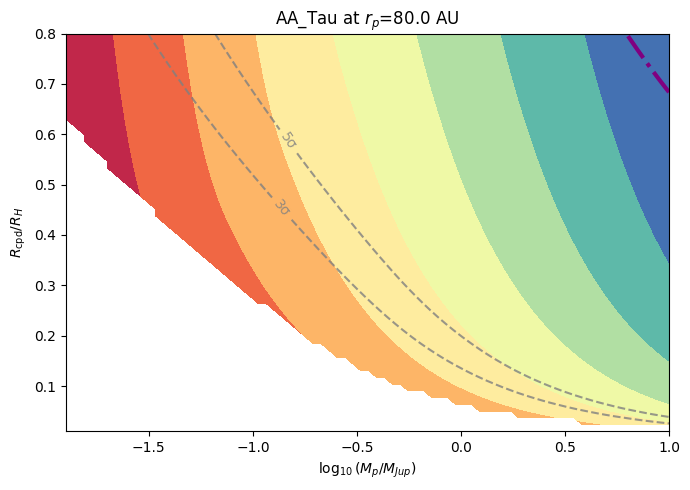

In [29]:
### Planet kink sources (one by one)

  # Format: [disk_name, radius_au, sigma_flux]
#["AA_Tau", 80, 136.85],

disk_name, radius_au, sigma_flux_ujy = kink_sources[0]
Mp_grid_AATau80, Rout_frac_grid_AATau80, Flux_vals_AATau80, M_cpd_chosen_AATau80 = compute_flux_map_zhu(
        target_flux_arr=[sigma_flux_ujy],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_mm=0.9,
        y_min =0.01,
        y_max=0.8,
        x_min=-2.0,
        x_max=1.0,
        alpha=1e-6
        )

# Plotfor 80
plot_flux_map_zhu(
    Mp_grid=Mp_grid_AATau80,
    Rout_frac_grid=Rout_frac_grid_AATau80,
    Flux_vals=Flux_vals_AATau80,
    M_cpd_vals=M_cpd_chosen_AATau80,
    disk_arr=disk_arr['AA_Tau'],
    target_flux_arr=disk_arr['AA_Tau'],
    rp= radius_au,
    lam_mm=0.8,
    alpha=1e-6,
    sigma_ujy=sigma_flux_ujy,
    plotmass=True,
    y_min=0.01,
    y_max=0.8,
    x_min=-1.9,
    x_max=1.0,
)

plt.colorbar(cf, orientation="vertical", pad=0.02).set_label(
    r"$\log_{10}(M_{\rm CPD}/M_{\rm Jup})$", fontsize=13
)
plt.tight_layout()
plt.show()

C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:41: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet / (4*np.pi*sigmaB*R**2))**0.25
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


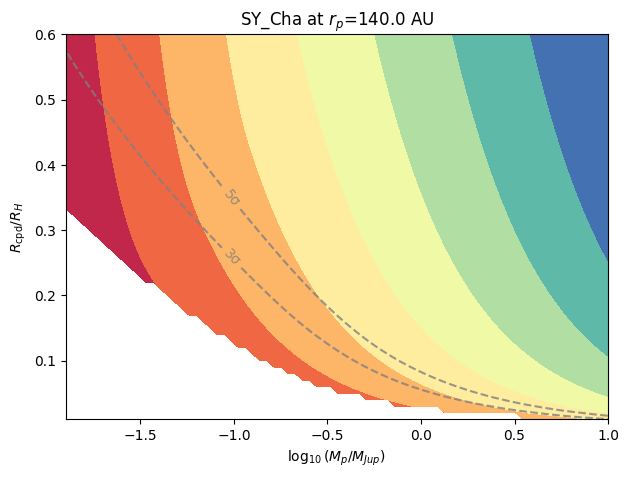

In [30]:
# SY_Cha at 140 au
disk_name, radius_au, sigma_flux_ujy = kink_sources[1]
Mp_grid_SYCha140, Rout_frac_grid_SYCha140, Flux_vals_SYCha140, M_cpd_chosen_SYCha140 = compute_flux_map_zhu(
        target_flux_arr=[sigma_flux_ujy],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_mm=0.9,
        y_min =0.01,
        y_max=0.6,
        x_min=-2.0,
        x_max=1.0,
        alpha=1e-6
        )
# Plotfor 140
plot_flux_map_zhu(
    Mp_grid=Mp_grid_SYCha140,
    Rout_frac_grid=Rout_frac_grid_SYCha140,
    Flux_vals=Flux_vals_SYCha140,
    M_cpd_vals=M_cpd_chosen_SYCha140,
    disk_arr=disk_arr['SY_Cha'],
    target_flux_arr=disk_arr['SY_Cha'],
    rp= radius_au,
    lam_mm=0.9,
    alpha=1e-6,
    sigma_ujy=sigma_flux_ujy,
    plotmass=True,
    y_min=0.01,
    y_max=0.6,
    x_min=-1.9,
    x_max=1.0,
)

C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:41: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet / (4*np.pi*sigmaB*R**2))**0.25
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


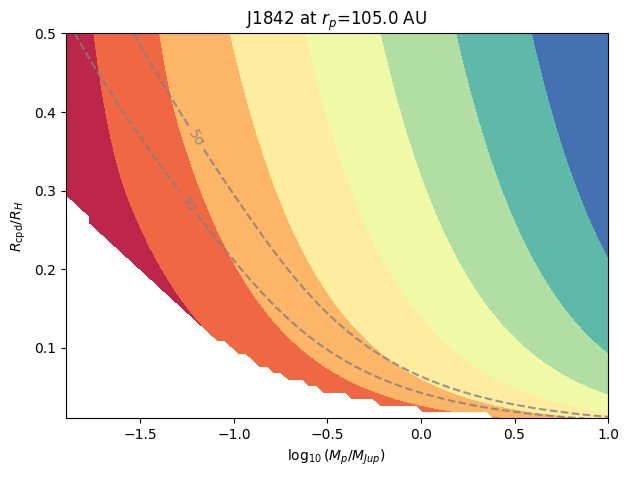

In [31]:
# J1842 at 105 au

disk_name, radius_au, sigma_flux_ujy = kink_sources[2]
Mp_grid_J1842105, Rout_frac_grid_J1842105, Flux_vals_J1842105, M_cpd_chosen_J1842105 = compute_flux_map_zhu(
        target_flux_arr=[sigma_flux_ujy],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_mm=0.9,
        y_min =0.01,
        y_max=0.5,
        x_min=-2.0,
        x_max=1.0,
        alpha=1e-6
        )
# Plotfor 105
plot_flux_map_zhu(
    Mp_grid=Mp_grid_J1842105,
    Rout_frac_grid=Rout_frac_grid_J1842105,
    Flux_vals=Flux_vals_J1842105,
    M_cpd_vals=M_cpd_chosen_J1842105,
    disk_arr=disk_arr['J1842'],
    target_flux_arr=disk_arr['J1842'],
    rp= radius_au,
    lam_mm=0.9,
    alpha=1e-6,
    sigma_ujy=sigma_flux_ujy,
    plotmass=True,
    y_min=0.01,
    y_max=0.5,
    x_min=-1.9,
    x_max=1.0,
)

C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:41: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet / (4*np.pi*sigmaB*R**2))**0.25
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


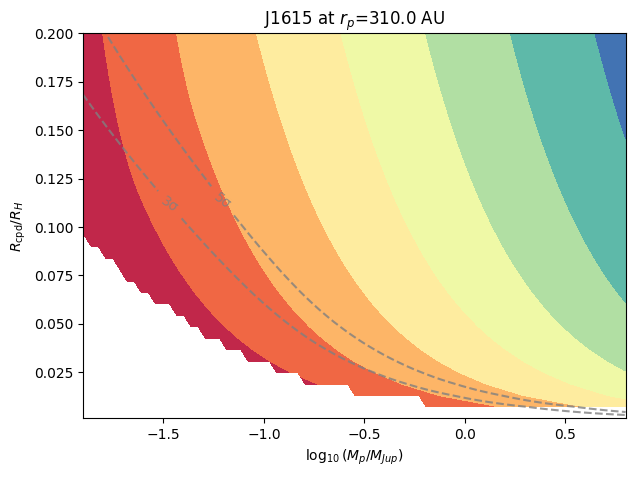

In [32]:
# J1615 at 310 au
disk_name, radius_au, sigma_flux_ujy = kink_sources[3]
Mp_grid_J1615310, Rout_frac_grid_J1615310, Flux_vals_J1615310, M_cpd_chosen_J1615310 = compute_flux_map_zhu(
        target_flux_arr=[sigma_flux_ujy],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_mm=0.9,
        y_min =0.001,
        y_max=0.35,
        x_min=-2.0,
        x_max=0.8,
        alpha=1e-6
        )
# Plotfor 310
plot_flux_map_zhu(
    Mp_grid=Mp_grid_J1615310,
    Rout_frac_grid=Rout_frac_grid_J1615310,
    Flux_vals=Flux_vals_J1615310,
    M_cpd_vals=M_cpd_chosen_J1615310,
    disk_arr=disk_arr['J1615'],
    target_flux_arr=disk_arr['J1615'],
    rp= radius_au,
    lam_mm=0.9,
    alpha=1e-6,
    sigma_ujy=sigma_flux_ujy,
    plotmass=True,
    y_min=0.001,
    y_max=0.2,
    x_min=-1.9,
    x_max=0.8,
)

C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:41: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet / (4*np.pi*sigmaB*R**2))**0.25
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


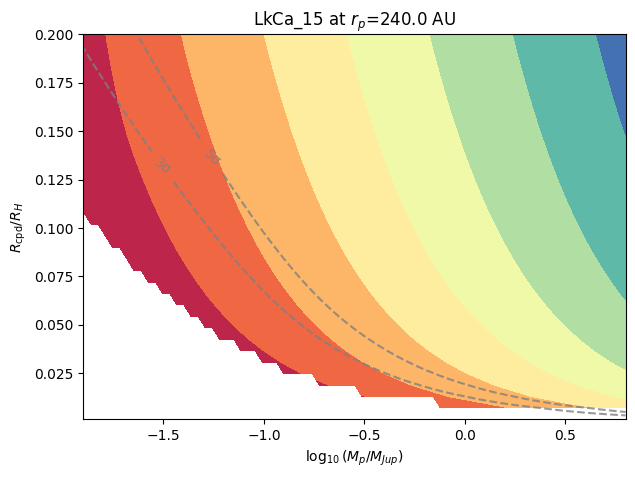

In [33]:
# LkCa 15 at 240 au
disk_name, radius_au, sigma_flux_ujy = kink_sources[4]
Mp_grid_LkCa15240, Rout_frac_grid_LkCa15240, Flux_vals_LkCa15240, M_cpd_chosen_LkCa15240 = compute_flux_map_zhu(
        target_flux_arr=[sigma_flux_ujy],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_mm=0.9,
        y_min =0.001,
        y_max=0.35,
        x_min=-2.0,
        x_max=0.8,
        alpha=1e-6
        )
# Plotfor 240
plot_flux_map_zhu(
    Mp_grid=Mp_grid_LkCa15240,
    Rout_frac_grid=Rout_frac_grid_LkCa15240,
    Flux_vals=Flux_vals_LkCa15240,
    M_cpd_vals=M_cpd_chosen_LkCa15240,
    disk_arr=disk_arr['LkCa_15'],
    target_flux_arr=disk_arr['LkCa_15'],
    rp= radius_au,
    lam_mm=0.9,
    alpha=1e-6,
    sigma_ujy=sigma_flux_ujy,
    plotmass=True,
    y_min=0.001,
    y_max=0.2,
    x_min=-1.9,
    x_max=0.8,
)

C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


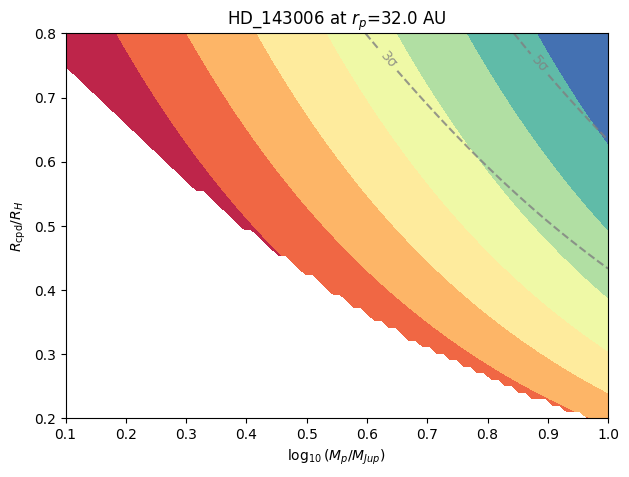

In [34]:
# HD 143006 at 32 au
disk_name, radius_au, sigma_flux_ujy = kink_sources[5]
Mp_grid_HD14300632, Rout_frac_grid_HD14300632, Flux_vals_HD14300632, M_cpd_chosen_HD14300632 = compute_flux_map_zhu(
        target_flux_arr=[sigma_flux_ujy],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_mm=0.9,
        y_min =0.2,
        y_max=0.8,
        x_min=0.1,
        x_max=1.0,
        alpha=1e-6
        )

# Plotfor 32
plot_flux_map_zhu(
    Mp_grid=Mp_grid_HD14300632,
    Rout_frac_grid=Rout_frac_grid_HD14300632,
    Flux_vals=Flux_vals_HD14300632,
    M_cpd_vals=M_cpd_chosen_HD14300632,
    disk_arr=disk_arr['HD_143006'],
    target_flux_arr=disk_arr['HD_143006'],
    rp= radius_au,
    lam_mm=0.9,
    alpha=1e-6,
    sigma_ujy=sigma_flux_ujy,
    plotmass=True,
    y_min=0.2,
    y_max=0.8,
    x_min=0.1,
    x_max=1.0,
)

AA Tau, r = 80 au: sigma_ujy=136.85, min/max Flux_vals=0.22319981875098818, 39503.15078595412
SY Cha, r = 140 au: sigma_ujy=57.23, min/max Flux_vals=0.2955816943414847, 37019.66556461614
J1842, r = 105 au: sigma_ujy=35.29, min/max Flux_vals=0.25696772862013606, 23621.245222146317
J1615, r = 310 au: sigma_ujy=24.56, min/max Flux_vals=0.04619882400811337, 39582.465897310656
LkCa 15, r = 240 au: sigma_ujy=20.14, min/max Flux_vals=0.032427340834618915, 27322.715398181306
HD 143006, r = 32 au: sigma_ujy=896.96, min/max Flux_vals=144.79757584292136, 6185.106104501506


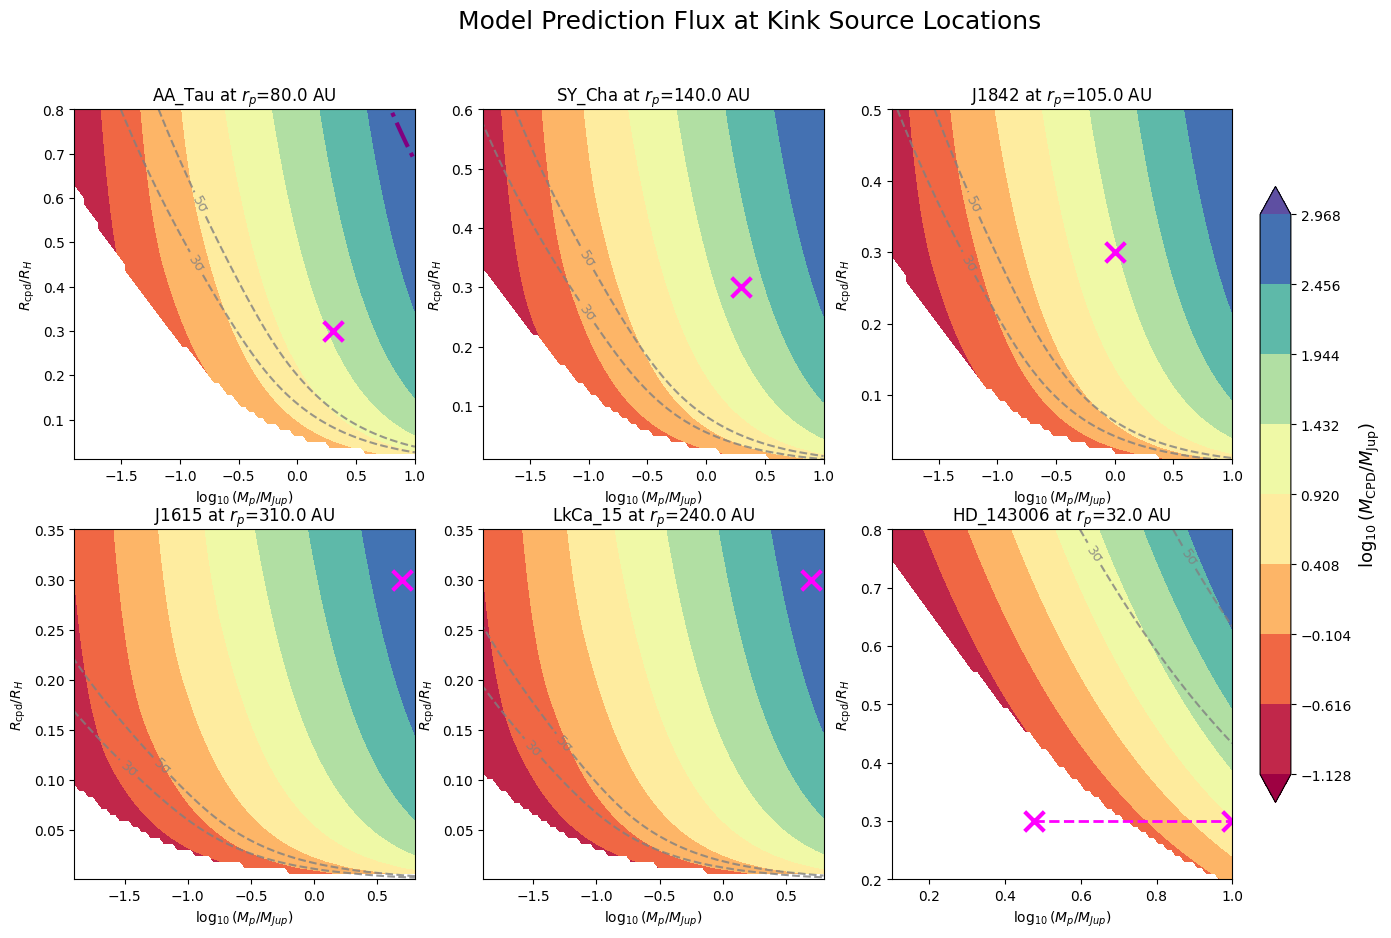

In [35]:
# now plot them in a subplots like the five sigma sources above

import numpy as np
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
cf_list = []

kink_configs = [
    {"idx": 0, "Mp_grid": Mp_grid_AATau80, "Rout_frac_grid": Rout_frac_grid_AATau80,
     "M_cpd_chosen": M_cpd_chosen_AATau80, "title": "AA Tau, r = 80 au", "y_lim": (0.01, 0.8), "x_lim": (-1.9, 1.0), "planet_mass": 2},
    {"idx": 1, "Mp_grid": Mp_grid_SYCha140, "Rout_frac_grid": Rout_frac_grid_SYCha140,
     "M_cpd_chosen": M_cpd_chosen_SYCha140, "title": "SY Cha, r = 140 au", "y_lim": (0.01, 0.6), "x_lim": (-1.9, 1.0), "planet_mass": 2},
    {"idx": 2, "Mp_grid": Mp_grid_J1842105, "Rout_frac_grid": Rout_frac_grid_J1842105,
     "M_cpd_chosen": M_cpd_chosen_J1842105, "title": "J1842, r = 105 au", "y_lim": (0.01, 0.5), "x_lim": (-1.9, 1.0), "planet_mass": 1},
    {"idx": 3, "Mp_grid": Mp_grid_J1615310, "Rout_frac_grid": Rout_frac_grid_J1615310,
     "M_cpd_chosen": M_cpd_chosen_J1615310, "title": "J1615, r = 310 au", "y_lim": (0.001, 0.35), "x_lim": (-1.9, 0.8), "planet_mass": 5},
    {"idx": 4, "Mp_grid": Mp_grid_LkCa15240, "Rout_frac_grid": Rout_frac_grid_LkCa15240,
     "M_cpd_chosen": M_cpd_chosen_LkCa15240,    "title": "LkCa 15, r = 240 au", "y_lim": (0.001, 0.35), "x_lim": (-1.9, 0.8), "planet_mass": 5},
    {"idx": 5, "Mp_grid": Mp_grid_HD14300632, "Rout_frac_grid": Rout_frac_grid_HD14300632,
     "M_cpd_chosen": M_cpd_chosen_HD14300632, "title": "HD 143006, r = 32 au", "y_lim": (0.2, 0.8), "x_lim": (0.1, 1.0), "planet_mass": [3,10]},       
]       

for i, cfg in enumerate(kink_configs):
    disk_name = kink_sources[cfg["idx"]][0]
    rp = kink_sources[cfg["idx"]][1]
    sigma_ujy = kink_sources[cfg["idx"]][2]
    disk_params = disk_arr[disk_name]

    # Add this line to get the correct Flux_vals for each source
    if disk_name == "AA_Tau":
        Flux_vals = Flux_vals_AATau80
    elif disk_name == "SY_Cha":
        Flux_vals = Flux_vals_SYCha140
    elif disk_name == "J1842":
        Flux_vals = Flux_vals_J1842105
    elif disk_name == "J1615":
        Flux_vals = Flux_vals_J1615310
    elif disk_name == "LkCa_15":
        Flux_vals = Flux_vals_LkCa15240
    elif disk_name == "HD_143006":
        Flux_vals = Flux_vals_HD14300632
    print(f"{cfg['title']}: sigma_ujy={sigma_ujy}, min/max Flux_vals={np.nanmin(Flux_vals)}, {np.nanmax(Flux_vals)}")
    cf = plot_flux_map_zhu(
        Mp_grid=cfg["Mp_grid"],
        Rout_frac_grid=cfg["Rout_frac_grid"],
        Flux_vals=Flux_vals,
        M_cpd_vals=cfg["M_cpd_chosen"],
        disk_arr=disk_params,
        target_flux_arr=[sigma_ujy],
        color = 'Spectral',
        rp=rp,
        lam_mm=0.9,
        alpha=1e-6,
        plotmass=True,
        sigma_ujy=sigma_ujy,
        y_min=cfg["y_lim"][0],
        y_max=cfg["y_lim"][1],
        x_min=cfg["x_lim"][0],
        x_max=cfg["x_lim"][1],
        ax=axes[i]
    )
    cf_list.append(cf)  
    planet_mass = cfg["planet_mass"]
    if isinstance(planet_mass, (list, tuple, np.ndarray)):
        # Plot two 'x' markers
        axes[i].scatter(np.log10(planet_mass), [0.3]*len(planet_mass), marker='x', color='magenta', s=200, linewidths=3, label='Planet')
        # Connect them with a horizontal dashed line
        axes[i].plot([np.log10(planet_mass[0]), np.log10(planet_mass[1])], [0.3, 0.3], color='magenta', linestyle='--', linewidth=2)
    else:
        axes[i].scatter(np.log10(planet_mass), 0.3, marker='x', color='magenta', s=200, linewidths=3, label='Planet')

#fig.tight_layout()
cbar = fig.colorbar(cf_list[0], ax=axes, orientation="vertical", shrink=0.8, pad=0.02)
cbar.set_label(r"$\log_{10}(M_{\rm CPD}/M_{\rm Jup})$", fontsize=13)

plt.suptitle("Model Prediction Flux at Kink Source Locations", fontsize=18)
plt.show()

### Check Tau behaviour

In [36]:
# separate functions to get Tb and Tau_mm modulise
# why is it a 1D array ->  Tb(r) -> fixed mp, accretion rate
# If sigma is changed?  and fixed r , sigma is changed by


In [37]:


def get_radial_grid(Rp, Rout, n_points=100):
    """Return radial grid from just outside Rp to Rout (in cm)."""
    return np.geomspace(Rp*1.01, Rout, n_points)

def get_luminosities(Mp, Mdot, Rp, Lstar, Lplanet, rp):
    """
        Return accretion, planet, and star irradiation luminosities.
        Input: Mp (g), Mdot (g/s), Rp (cm), Lstar (erg/s), Lplanet (erg/s), rp (cm)
    
    """
    L_irr = G * Mp * Mdot / (2.0 * Rp)
    phi_flare = 0.02
    return L_irr, Lplanet, phi_flare * Lstar / (8 * np.pi * sigmaB * rp**2)

def get_temperatures(R, L_irr, Lplanet, T_ISM, Lstar_irr, rp):
    """
    Return irradiation temperatures at each radius.
    """
    # Irradiation temperatures for star and planet
    T_irr = (L_irr / (40 * np.pi * sigmaB * R**2))**0.25
    T_irr_p = (0.1 * Lplanet / (4 * np.pi * sigmaB * R**2))**0.25
    T_irr_star = Lstar_irr**0.25
    # Total external temperature
    T_ext = (T_irr**4 + T_irr_p**4 + T_irr_star**4 + T_ISM**4)**0.25
    return T_irr, T_irr_p, T_irr_star, T_ext

def get_surface_density(R, Mp, Mdot, alpha, kappaR, mu, Rp, T_ext):
    """Return Sigma profile using Zhu et al. (2018) prescriptions."""
    Rgas = 8.314e7  # erg/(mol K)
    term = (sigmaB * G * Mp * Mdot**3 / (alpha**4 * (np.pi**3) * kappaR))**0.2
    mu_term = (mu / Rgas)**0.8
    factor = (1 - np.sqrt(Rp / R))**(3/5)
    Sigma6 = ((2**(7/5)) / (3**(6/5))) * term * mu_term * factor * R**(-3/5)
    Omega = np.sqrt(G * Mp / R**3)
    Sigma7 = (Mdot * mu * Omega) / (3.0 * np.pi * alpha * Rgas * T_ext)
    return np.minimum(Sigma6, Sigma7)

def get_temperatures_central(R, Mp, Mdot, Sigma, kappaR, Rp, T_ext):
    """Return central and effective temperatures."""
    A = (9 * G * Mp * Mdot * Sigma * kappaR) / (128 * np.pi * sigmaB * R**3)
    f = (1.0 - np.sqrt(Rp / R))
    T_c = (A * f + T_ext**4)**0.25
    Teff = ((3.0 * G * Mp * Mdot) / (8.0 * np.pi * sigmaB * R**3) * (1.0 - np.sqrt(Rp / R)))**0.25
    return T_c, Teff

def get_brightness_temperature_from_tay(Sigma, T_c, Teff, T_ext, kappaR, tau_mm):
    """Return brightness temperature profile."""
    # kappa_mm = 0.034 * (0.87 / lam_mm)
    # tau_mm = 0.5 * kappa_mm * Sigma
    Tb_thin = 2.0 * tau_mm * T_c
    Tb_thick = ((3.0/8.0) * (kappaR )*(0.5*Sigma/tau_mm)* Teff**4 + T_ext**4)**0.25
    Tb = np.where(tau_mm <= 0.5, Tb_thin, Tb_thick)
    return Tb



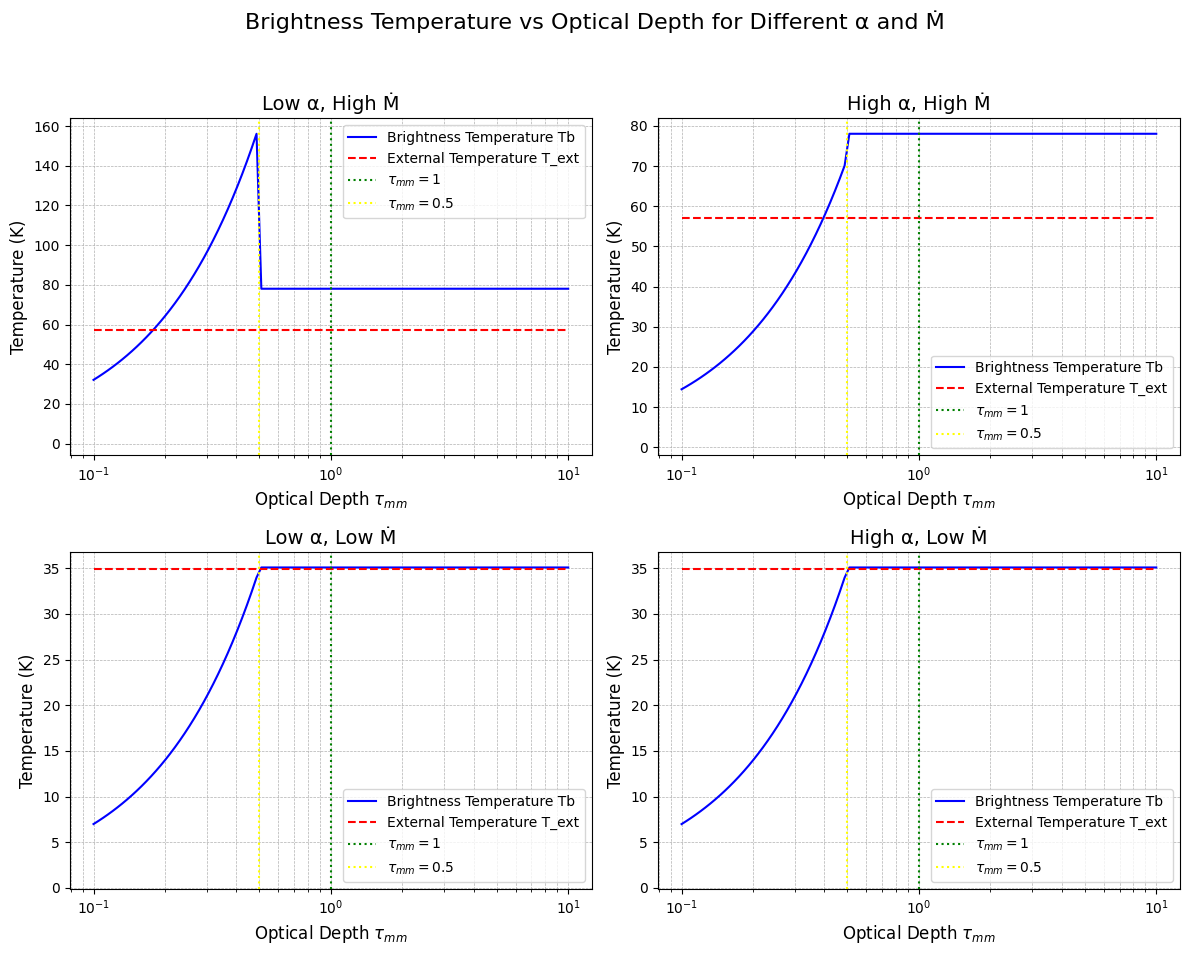

In [38]:
# Plot Tau_mm against Tb for different MpMpdot, alpha:

# Define a funciton to relate Tb to tau in optically thick regime
def Tb_from_tau_thick(R, tau_mm, Tc, Teff, T_ext, kappaR, Sigma):
    # thin approx
    Tb_thin = 2 * tau_mm * Tc

    # thick approx (Zhu eq. 8 adaptation)
    kappamm = 0.034 * (0.87 / 0.9) 
    Tb_thick = ((3/8)*(kappaR/kappamm)*Teff**4 + T_ext**4)**0.25

    Tb = np.where(tau_mm <= 0.5, Tb_thin, Tb_thick)
    return Tb

# First determine Sigma, Tc, Teff at R = 1 au, Mp = 5*Mjup, Mdot, alpha
def Tb_against_tau(R_fix, Mp, Mdot, alpha, tau_mm):

    M_star, Mp_cgs, Mdot_cgs, rp_cgs, Lstar_cgs, Rp_cgs, Lplanet = convert_inputs(1.0, Mp, Mdot, 20, 1.0)
    
    Rout_cgs = (1/3)*rp_cgs*(Mp_cgs/(3*M_star))**(1/3)

    R = R_fix * AU

    # Calulate the temperate at the R 

    T_ext, T_irr, T_irr_p, T_irr_star = irradiation_temperature(R, Rp_cgs, Mp_cgs, Mdot_cgs,
                                                               Lplanet, Lstar_cgs, rp_cgs, T_ISM=10)
    Teff  = effective_temperature(R, Rp_cgs, Mp_cgs, Mdot_cgs)


    # Surface density
    kappaR = 10  # cm2/g
    mu     = 2.34  # g/mol
    Sigma6 = sigma_viscous(R, Rp_cgs, Mp_cgs, Mdot_cgs, alpha, kappaR, mu)
    Sigma7 = sigma_irradiated(R, Mp_cgs, Mdot_cgs, alpha, mu, T_ext)
    Sigma  = sigma_combined(Sigma6, Sigma7)

    # Central temperature
    Tc = midplane_temperature(R, Rp_cgs, Mp_cgs, Mdot_cgs, Sigma, kappaR, T_ext)

    # Tb

    Tb = Tb_from_tau_thick(R, tau_mm, Tc, Teff, T_ext, kappaR, Sigma)

    return Tb, T_ext

# Create the tau_mm array
tau_mm_array = np.logspace(-1, 1, 100)  # from 0.01 to 100

alpha_arr = [1e-2, 1e-4, 1e-6]
Mdot_arr = [1e-8, 1e-6, 1e-5]   # Mjup/yr
    

a,b = Tb_against_tau(1, 5, 1e-8, 1e-2, tau_mm_array)


# Plot a plot of 4 subplots , 
# upper left: low alpha , high Mdot (alpha=1e-4, Mdot=1e-5)
# upper right: high alpha, low Mdot (alpha=1e-1, Mdot=1e-5)
# lower left: low alpha, high Mdot (alpha=1e-4, Mdot=1e-8)
# lower right: hight alpha, low Mdot (alpha=1e-1, Mdot=1e-8)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()                                                                   
configurations = [
    {"alpha": 1e-4, "Mdot": 1e-5, "title": "Low α, High Ṁ"},   
    {"alpha": 1e-2, "Mdot": 1e-5, "title": "High α, High Ṁ"},
    {"alpha": 1e-4, "Mdot": 1e-8, "title": "Low α, Low Ṁ"},
    {"alpha": 1e-2, "Mdot": 1e-8, "title": "High α, Low Ṁ"},
]

for i, config in enumerate(configurations):
    alpha = config["alpha"]
    Mdot = config["Mdot"]
    Tb_values, T_ext_values = Tb_against_tau(1, 5, Mdot, alpha, tau_mm_array)

    axes[i].loglog(tau_mm_array, Tb_values, label='Brightness Temperature Tb', color='blue')
    axes[i].hlines(T_ext_values, xmin=tau_mm_array[0], xmax=tau_mm_array[-1], colors='red', linestyles='--', label='External Temperature T_ext')

    axes[i].set_title(config["title"], fontsize=14)
    axes[i].set_xlabel(r'Optical Depth $\tau_{mm}$', fontsize=12)
    axes[i].set_ylabel('Temperature (K)', fontsize=12)
    axes[i].grid(True, which="both", ls="--", lw=0.5)
    axes[i].set_yscale("linear")
    axes[i].axvline(1, color='green', linestyle=':', label=r'$\tau_{mm}=1$')
    axes[i].axvline(0.5, color='yellow', linestyle=':', label=r'$\tau_{mm}=0.5$')
    axes[i].legend()

plt.suptitle('Brightness Temperature vs Optical Depth for Different α and Ṁ', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



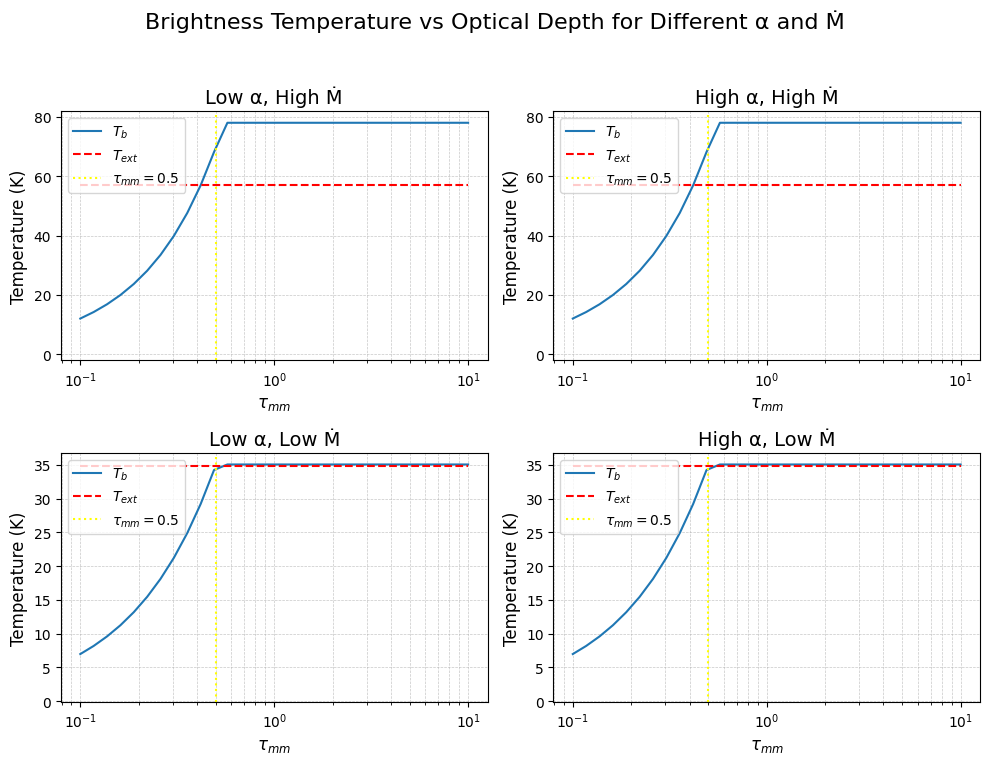

In [39]:
def Tb_vs_tau_mm_fixed_params(R_au, Mp, Mdot, alpha, kappaR=10, mu=2.34, lam_mm=0.9):
    R = R_au * AU
    kappa_mm = 0.034 * (0.87 / lam_mm)
    tau_mm_arr = np.logspace(-1, 1, 30)
    Tb_arr = []
    T_ext_arr = []
    for tau_mm in tau_mm_arr:
        Sigma = tau_mm / (0.5 * kappa_mm)
        # Recompute temperatures for each Sigma
        M_star, Mp_cgs, Mdot_cgs, rp_cgs, Lstar_cgs, Rp_cgs, Lplanet = convert_inputs(1.0, Mp, Mdot, 20, 1.0)
        T_ext, T_irr, T_irr_p, T_irr_star = irradiation_temperature(R, Rp_cgs, Mp_cgs, Mdot_cgs, Lplanet, Lstar_cgs, rp_cgs, T_ISM=10)
        Teff = effective_temperature(R, Rp_cgs, Mp_cgs, Mdot_cgs)
        Tc = midplane_temperature(R, Rp_cgs, Mp_cgs, Mdot_cgs, Sigma, kappaR, T_ext)
        Tb_thin = 2 * tau_mm * Tc
        Tb_thick = ((3/8)*(kappaR/kappa_mm)*Teff**4 + T_ext**4)**0.25
        Tb = Tb_thin if tau_mm <= 0.5 else Tb_thick
        Tb_arr.append(Tb)
        T_ext_arr.append(T_ext)
    return tau_mm_arr, np.array(Tb_arr), np.array(T_ext_arr)

#2x2 plot for different alpha and accretion rate combinations

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

configs = [
    {"alpha": 1e-4, "Mdot": 1e-5, "title": "Low α, High Ṁ"},
    {"alpha": 1e-2, "Mdot": 1e-5, "title": "High α, High Ṁ"},
    {"alpha": 1e-4, "Mdot": 1e-8, "title": "Low α, Low Ṁ"},
    {"alpha": 1e-2, "Mdot": 1e-8, "title": "High α, Low Ṁ"},
]

for i, cfg in enumerate(configs):
    tau_mm_arr, Tb_arr, T_ext_arr = Tb_vs_tau_mm_fixed_params(
        R_au=1, Mp=5, Mdot=cfg["Mdot"], alpha=cfg["alpha"], kappaR=10, mu=2.34, lam_mm=0.9
    )
    axes[i].loglog(tau_mm_arr, Tb_arr, label='$T_b$')
    axes[i].hlines(T_ext_arr.mean(), tau_mm_arr[0], tau_mm_arr[-1], colors='red', linestyles='--', label='$T_{ext}$')
    axes[i].set_title(cfg["title"], fontsize=14)
    axes[i].set_xlabel(r'$\tau_{mm}$', fontsize=12)
    axes[i].set_ylabel('Temperature (K)', fontsize=12)
    axes[i].grid(True, which="both", ls="--", lw=0.5, alpha=0.7)
    axes[i].set_yscale("linear")
    axes[i].set_xscale("log")
    #axes[i].axvline(1, color='green', linestyle=':', label=r'$\tau_{mm}=1$')
    axes[i].axvline(0.5, color='yellow', linestyle=':', label=r'$\tau_{mm}=0.5$')
    axes[i].legend()

plt.suptitle('Brightness Temperature vs Optical Depth for Different α and Ṁ', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In the context of the Zhu model, when both the accretion rate $\dot{M_p}$ and planet mass $M_p$ are held fixed, the physical surface density $\Sigma(R)$ at a given radius is uniquely determined by these parameters and the disk viscosity  $\alpha$. The external irradiation temperature is independent of $\Sigma$, while the midplane temperature $T_c$ does depend on $\Sigma$. In the optically thin regime, the brightness temperature $T_b$ is sensitive to changes in $T_c$ and thus to $\Sigma$. However, in the optically thick regime, $T_b$ becomes independent of $\Sigma$ and is instead set by the effective temperature and irradiation. Therefore, varying $\Sigma$ at fixed radius without adjusting underlying physical parameters such as $R$, $R_{\rm out}$)$, $\dot{M_p}$, or $M_p$ is not physically self-consistent. This approach is useful for illustrating radiative transfer effects, but it does not represent a physically plausible disk structure, and the low optical depth regime in such plots may be inaccurate for the chosen disk parameters.




low alpha high Mdot & high alpha high Mdot:  the flux is independent of alpha becuase it is optiaclly thick
Low Mdot 

In [40]:
# Plot figure 8：
# can try to separate viscous heating and irradiation heating contributions -> to get two separate plots
# cant use kappa_mm to get tau , 

# add kappa_mm dependence on tau_mm\
# rout increase so flux wouldnt saturate 
# can try to fix Rout in Mp , mdot 
# viscosity 
# seans plot  ->  as accretion fix  -> different alpha 
# Both ways can do some constraint
# use 0.01  d/g fix the mass 
# double check which one is dust mass , or gas mass 
# check the opacity for each  ( in surface density or )
# Andrews flux vs radius 
# Undestand simga vs rout in andrewa
# zhu model -> 0.3 rhill , unreosolved limit Mcpd
# to do translte this into written paragraph can train written clarity

### Verify masses

C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\3146149240.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]


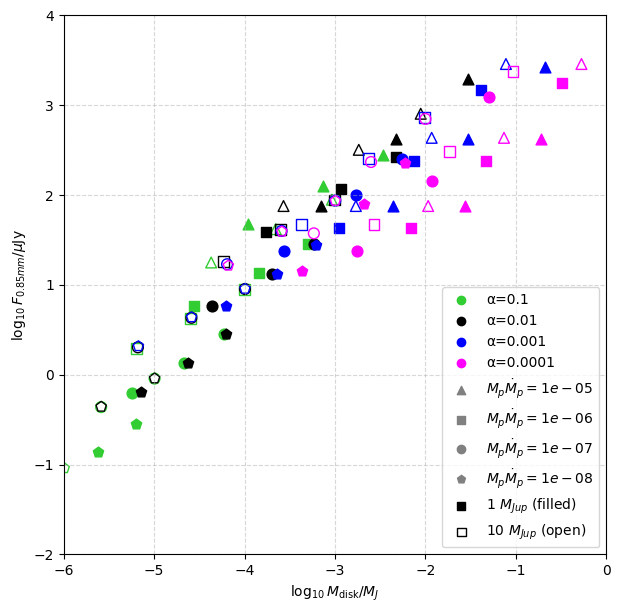

In [41]:
import numpy as np

alphas = [0.1, 0.01, 1e-3, 1e-4]
MpMdot_vals = [1e-5, 1e-6, 1e-7, 1e-8]
markers = ['^', 's', 'o', 'p']  # triangle, square, circle, pentagon
colors = ['limegreen', 'black', 'blue', 'magenta']
Rout_vals = [0.12, 0.46, 1.85]  # AU

results = []

for a_idx, alpha in enumerate(alphas):
    for m_idx, MpMdot in enumerate(MpMdot_vals):
        for Mp in [1, 10]:  # 1 and 10 Mjup
            Mdot = MpMdot / Mp
            for Rout in Rout_vals:
                out = calculate_disk_properties_zhu(
                    M_star=1.0, Mp=Mp, Mdot=Mdot, alpha=alpha, rp=20,
                    lam_mm=0.85, Rout=Rout, d_pc=140, Lstar=1.0
                )
                logMdisk = np.log10(out['M_dust'])
                logFlux = np.log10(out['F_nu_tot'])
                # Marker style: filled for Mp=1, open for Mp=10
                if Mp == 1:
                    marker_style = dict(marker=markers[m_idx], facecolors=colors[a_idx], edgecolors=colors[a_idx], label='1 $M_{Jup}$')
                else:
                    marker_style = dict(marker=markers[m_idx], facecolors='none', edgecolors=colors[a_idx], label='10 $M_{Jup}$')
                results.append({
                    'alpha': alpha, 'MpMdot': MpMdot,
                    'Mp': Mp, 'Rout': Rout,
                    'logMdisk': logMdisk, 'logFlux': logFlux,
                    'color': colors[a_idx], 'marker': markers[m_idx],
                    'marker_style': marker_style
                })
# Plot
# Plot
plt.figure(figsize=(7,7))
for r in results:
    plt.scatter(
        r['logMdisk'], r['logFlux'],
        s=60,
        marker=r['marker_style']['marker'],
        facecolors=r['marker_style']['facecolors'],
        edgecolors=r['marker_style']['edgecolors']
    )

# Legend for alpha (color)
for i, alpha in enumerate(alphas):
    plt.scatter([], [], color=colors[i], marker='o', label=f'α={alpha}')

# Legend for MpMdot (marker shape)
for i, MpMdot in enumerate(MpMdot_vals):
    plt.scatter([], [], color='gray', marker=markers[i], label=f'$M_p\\dot{{M}}_p={MpMdot:.0e}$')

# Legend for Mp (filled/open)
plt.scatter([], [], marker='s', facecolors='black', edgecolors='black', label='1 $M_{Jup}$ (filled)')
plt.scatter([], [], marker='s', facecolors='none', edgecolors='black', label='10 $M_{Jup}$ (open)')

plt.xlabel(r'$\log_{10} M_{\rm disk}/M_J$')
plt.ylabel(r'$\log_{10} F_{0.85mm}/\mu{\rm Jy}$')
plt.legend()
plt.ylim(-2, 4)
plt.xlim(-6, 0)
plt.grid(True, ls='--', alpha=0.5)
plt.show()

It looks alright to me

### The Zhu's plot for kinks and so on

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import sys
import os

# Add model directory to path
model_dir = r'D:\CPD_MPIA\CPD_Emission_Models'
if model_dir not in sys.path:
    sys.path.append(model_dir)

import Zhu_model
import Dictionaries

# Load dictionaries
disk_arr = Dictionaries.disk_arr
five_sigma_sources = Dictionaries.five_sigma_sources
kink_sources = Dictionaries.kink_sources

# ============================================================
# GLOBAL VISUAL STYLE
# ============================================================
rcParams["font.size"] = 14
rcParams["font.family"] = "serif"
rcParams["axes.linewidth"] = 1.0
rcParams["xtick.direction"] = "in"
rcParams["ytick.direction"] = "in"

In [56]:
def plot_all_zhu_sources(sources, source_type="5sigma", alpha=1e-3):
    n_sources = len(sources)
    ncols = 2
    nrows = (n_sources + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5*nrows))
    if n_sources == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    # collect mappables and used axes
    mappables = []
    used_axes = []

    for idx, source in enumerate(sources):
        ax = axes[idx]
        used_axes.append(ax)

        disk_name = source[0]
        rp = source[1]
        # flux value: use 5σ per-source rms if provided in list (for five_sigma_sources it’s index 3)
        flux_ujy = source[3]

        Mp_grid = np.logspace(-2, 1, 60)       # 0.1–10 Mjup
        Mdot_grid = np.logspace(-9, -5, 60)    # 1e-9 – 1e-5 Mjup/yr

        # 2. Compute flux for a fixed Rout/RH (e.g., 0.3)
        disk_arr = disk_arr[disk_name]
        Flux_vals = np.zeros((len(Mdot_grid), len(Mp_grid)))
        for i, Mdot in enumerate(Mdot_grid):
            for j, Mp in enumerate(Mp_grid):

                RHill = rD22 * (Mp / (3 * 1047.56 * disk_arr[1]))**(1/3)
                Rout = 0.3 * RHill

                out = calculate_disk_properties_zhu(
                    M_star = disk_arr[1],
                    Mp = Mp,
                    Mdot = Mdot,
                    alpha = alpha,
                    rp = rp,
                    d_pc = disk_arr[2],
                    lam_mm = 0.9,
                    Rout = Rout,
                    Lstar = disk_arr[3],
                )

                Flux_vals[i, j] = out["F_nu_tot"]

        # Plot and collect mappable for shared colorbar
        cf = Zhu_model.plot_zhu_Mp_Mdot_flux(
            Mp_grid, Mdot_grid, Flux_vals,
            disk_arr=disk_arr[disk_name],
            rp=rp,
            alpha=alpha,
            target_flux_arr=[flux_ujy],
            ax=ax
        )
        mappables.append(cf)

        ax.set_title(f"{disk_name} @ r={rp:.1f} AU ({source_type})",
                     fontsize=14, fontweight='bold')

    # Hide unused subplots
    for idx in range(n_sources, len(axes)):
        axes[idx].axis('off')

    # ---------------------------
    # Shared colorbar for all plots
    # ---------------------------
    # Use first mappable; they share the same normalization from plot_zhu_Mp_Mdot_flux
    if mappables:
        # Attach to only the axes that were used; location on the right
        cbar = fig.colorbar(mappables[0], ax=used_axes, fraction=0.02, pad=0.02)
        cbar.set_label(r"$\log_{10}(F_\nu\, [\mu{\rm Jy}])$", fontsize=rcParams['font.size'])

    #plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# PLOT KINK SOURCES
# ============================================================
print("\nPlotting kink sources...")
plot_all_zhu_sources(kink_sources, source_type="kink", alpha=1e-4)

C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\55144008.py:41: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet / (4*np.pi*sigmaB*R**2))**0.25
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\55144008.py:139: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / M_jup                  # [Earth masses]
C:\Users\LHEM\AppData\Local\Temp\ipykernel_19504\2888597568.py:86: RuntimeWarning: invalid value encountered in scalar power
  T_pirr[i,j] = (0.1 * Lp / (4*np.pi*sigmaB*R**2))**0.25


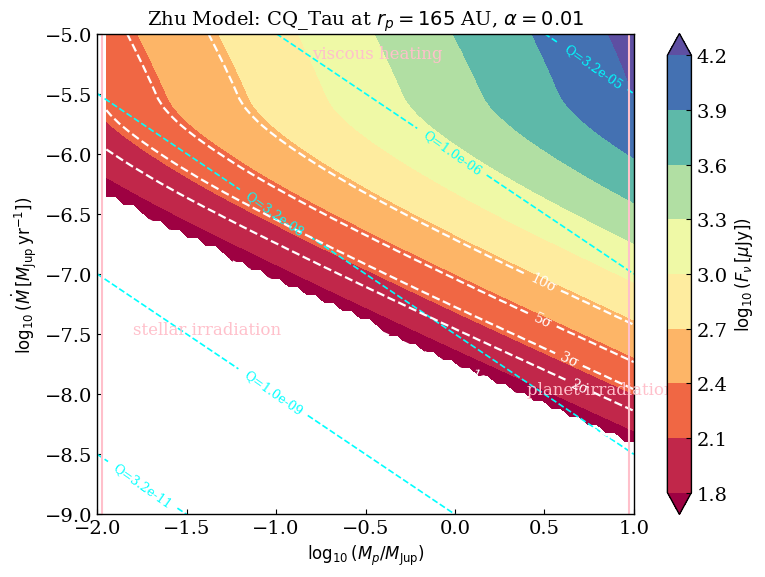

In [100]:

disk_arr =  ["CQ_Tau", 1.4, 149, 10, 0.135, 35.24, "05 35 58.467", "+24 44 54.091"]
target_flux_arr = [46]

# 1. Build Mp–Mdot grid
Mp_grid = np.logspace(-2, 1, 60)       # 0.1–10 Mjup
Mdot_grid = np.logspace(-9, -5, 60)    # 1e-9 – 1e-5 Mjup/yr

# 2. Compute flux for a fixed Rout/RH (e.g., 0.3)
Flux_vals = np.zeros((len(Mdot_grid), len(Mp_grid)))
for i, Mdot in enumerate(Mdot_grid):
    for j, Mp in enumerate(Mp_grid):

        RHill = 165 * (Mp / (3 * 1047.56 * disk_arr[1]))**(1/3)
        Rout = 0.3 * RHill

        out = calculate_disk_properties_zhu(
            M_star = disk_arr[1],
            Mp = Mp,
            Mdot = Mdot,
            alpha = 1e-3,
            rp = 165,
            d_pc = disk_arr[2],
            lam_mm = 0.9,
            Rout = Rout,
            Lstar = disk_arr[3],
        )

        Flux_vals[i, j] = out["F_nu_tot"]

# 3. Plot
plot_zhu_Mp_Mdot_flux(
    Mp_grid, Mdot_grid, Flux_vals,
    disk_arr=disk_arr,
    rp=165,
    alpha=1e-2,
    target_flux_arr=target_flux_arr
)


rp is too big!!!!

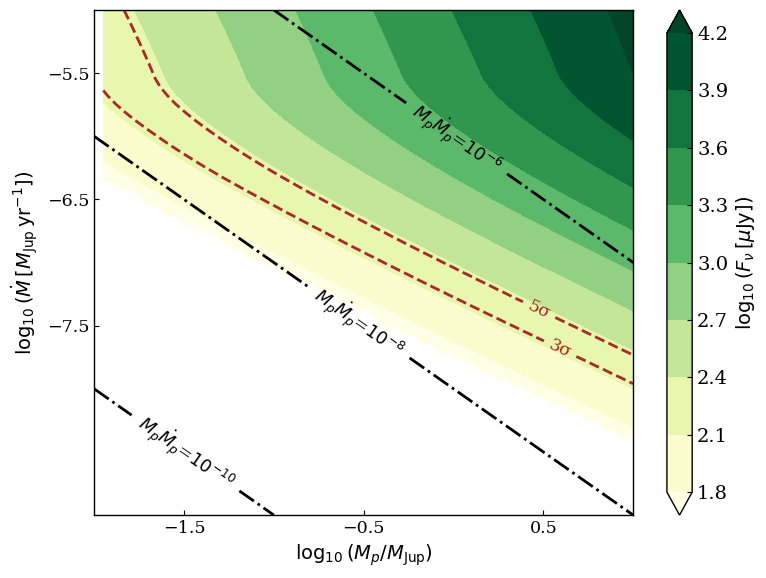

In [67]:

Zhu_model.plot_zhu_Mp_Mdot_flux(
    Mp_grid, Mdot_grid, Flux_vals,
    disk_arr=disk_arr,
    rp=165,
    alpha=1e-2,
    target_flux_arr=target_flux_arr
)
